# 04 - Decision-focused learning on the simulated panel

The DFL model of the methodology chapter (S3.2.4): the interpretable PD forecast is kept,
`pd_hat_{t+1} = f_theta(x_t)` (eq. 3.49), but trained end-to-end on decision regret
(eq. 3.33) through the differentiable allocation layer `alpha* (pd_hat)` (eq. 3.50). The
harness is copied from `03_blackbox_simulated_panel` / `02_pto_simulated_panel` - same
load/align, decision environment, evaluation, metrics and plots - and the PTO models plus
both persistence baselines are **re-run here on identical expanding windows**, so every
Diebold-Mariano comparison shares the same test dates.

**The allocation layer.** The forward decision solves the smooth forecast-based objective
(eq. 3.24/3.25) - expected terminal capital minus the lambda-weighted Vasicek expected
shortfall penalty - continuously by **bisection on the first-order condition** F = 0,
not on the 0.01 alpha grid. The backward pass never differentiates through the solver:
by the **implicit function theorem** on the FOC,

    dalpha*/dpd = - (dF/dpd) / (dF/dalpha) |_(alpha*),

with both partials in closed form (dF/dalpha = -lambda f_L(x) / (ell alpha^3 LGD) < 0 by
strict concavity, so the ratio is well defined at any interior optimum; boundary optima
get an exactly-zero gradient). A grid argmax would make alpha*(pd) a step function with
zero gradient almost everywhere and DFL would silently fail to train - the continuous
solve is what makes the method possible. Full DFL chain rule (eq. 3.52):
realised regret subgradient (torch, eq. 3.43) x IFT ratio (custom backward) x network
Jacobian (autodiff).

Shared with notebooks 02/03 (fairness rule): features and timing, per-window scaler,
expanding windows with `REFIT_EVERY`, alpha grid for EVALUATION (the continuous DFL
optimum is snapped to the shared grid at evaluation only), realised evaluation at
`K_IRB_true_{t+1}`, the two-oracle regret decomposition, DM machinery, and architecture
capacity / hyperparameter budget (identical linear and MLP bodies with a sigmoid head,
eq. 3.30-3.31, output read as PD). Training signal is identical to the black box
(realised `c_{t+1}`, `K_IRB_true_{t+1}`, foresight-oracle utility).

Different by design vs both benchmarks: unlike PTO the forecast is trained on the
downstream objective; unlike the black box the PD intermediate survives, so **all PD
accuracy/calibration diagnostics apply to DFL** - the auditability comparison of the
thesis. Documented gradient simplification: the Vasicek/IRB correlation rho = R(pd_a)
is held FIXED when differentiating (the correlation channel R'(pd) is omitted from the
gradient; the forward pass always evaluates the exact rho). The gradient-audit cell
quantifies the omitted channel against a full finite difference.

In [17]:
from __future__ import annotations

import json
import time
from dataclasses import dataclass
from pathlib import Path
from minou_colors import MINOU_COLORS

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook needs PyTorch for the linear and MLP PTO models. "
        "Install the project requirements or select the project kernel."
    ) from exc

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data" / "simulated_pd_panel.csv").exists():
    ROOT = ROOT.parent

PANEL_CSV = ROOT / "data" / "simulated_pd_panel.csv"
METADATA_PATH = ROOT / "data" / "simulated_pd_panel_metadata.json"
FIGURES_DIR = ROOT / "figures" / "dfl_pd_irb_sim"
RESULTS_DIR = ROOT / "models" / "notebooks" / "results" / "simulation" / "dfl"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Panel: {PANEL_CSV.relative_to(ROOT)}")
print(f"Figures: {FIGURES_DIR.relative_to(ROOT)}")
print(f"Results: {RESULTS_DIR.relative_to(ROOT)}")

Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Panel: data/simulated_pd_panel.csv
Figures: figures/dfl_pd_irb_sim
Results: models/notebooks/results/simulation/dfl


## Configuration

Decision and Basel constants are read from the simulator's metadata JSON so the two
notebooks cannot silently diverge; the asserts below fail loudly if the panel was built
with different constants than expected.

The simulated panel is long (~1000 quarters), so refitting every window is unnecessary
and slow. `REFIT_EVERY = 8` refits the scaler and models every 8th test quarter and
reuses them in between (predictions are still one-step-ahead and use only past data).
Set `REFIT_EVERY = 1` to reproduce the strict every-window protocol of the empirical
notebook. `ModelConfig` uses a larger batch and fewer epochs than the empirical notebook
because the training windows are roughly 5x longer.
The `LOSS` / `NLL_*` / `BIAS_CORRECTION` switches govern the **PTO predictor only**,
re-run here unchanged for the aligned comparison. The DFL model does not predict PD and
does not use the NLL; it trains on realised regret (see the dedicated section below).
`DFL_SEEDS` / `DFL_MODEL_CFG` pin the DFL model to the same seed-ensemble effort and
capacity/optimiser/early-stopping budget as the PTO MLP (fairness rule).


In [18]:
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    META = json.load(f)
CONST = META["constants"]

# Decision and Basel constants (from the simulator, asserted rather than assumed)
LGD = float(CONST["LGD"])
M = float(CONST["M"])
K1 = float(CONST["K1"])
LEVERAGE = float(CONST["ell"])
Y_BAR = float(CONST["Y_BAR"])
LAMBDA = float(CONST["lambda_shortfall"])
APPLY_PD_FLOOR = bool(CONST.get("APPLY_PD_FLOOR", True))
PD_FLOOR = float(CONST.get("PD_FLOOR", 3e-4))
assert LGD == 0.45 and K1 == 1.0 and LEVERAGE == 10.0, "Panel constants differ from expected calibration."

PD_Q_CLIP_LOW = 1e-6
PD_Q_CLIP_HIGH = 0.99
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99
ALPHA_GRID = np.linspace(0.0, 1.0, int(CONST.get("alpha_grid_size", 101)))

# Data conventions
HORIZON = 1
DATE_COL = "date"
FEATURE_COLS = list(META["feature_cols"])

# Modelling choices (mirroring the empirical notebook)
TARGET_TRANSFORM = "logit"      # "logit" or "level"
TRAIN_TARGET = "realised"       # "realised" (c_{t+1}/LGD, default) or "true" (ablation)
MLP_SEEDS = (42, 43, 44, 45, 46)
REFIT_EVERY = 8                # 1 = strict every-window refits

# Decision-stage and bias-correction choices (see the dedicated markdown section below)
DECISION_RULE = "expected"      # "expected" (max E[U] under Vasicek given pd_hat) or "certainty"
BIAS_CORRECTION = True          # median-bias inversion; only active when LOSS == "mse"
RHO_SCALE = float(CONST.get("RHO_SCALE", 1.0))
GH_NODES = 64                   # Gauss-Hermite nodes for expected-utility quadrature

# Training loss. "nll_vasicek" fits PD by maximum likelihood under the Vasicek density of
# realised rates (in the simulation this is the exact data-generating process, so it is
# the correct likelihood). It targets the MEAN PD directly, so the median-bias correction
# is unnecessary and automatically disabled. "mse" reproduces the MSE pipeline (with the
# correction re-enabled via BIAS_CORRECTION).
LOSS = "nll_vasicek"            # "nll_vasicek" or "mse"
NLL_RHO_MODE = "basel"          # "basel" (rho = NLL_RHO_SCALE * BaselR; exact DGP here) or
                                # "auto" (estimate residual probit variance per window -
                                # the right choice for aggregate empirical data)
NLL_RHO_SCALE = RHO_SCALE       # likelihood correlation = Basel R times this (basel mode)
if LOSS == "nll_vasicek" and TRAIN_TARGET == "true":
    print("WARNING: Vasicek NLL assumes noisy realised targets; use LOSS='mse' for the "
          "TRAIN_TARGET='true' ablation.")

EVAL_SPLITS = {
    "main": {"initial_train_frac": 0.7},
}

@dataclass
class ModelConfig:
    hidden_dim: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 64
    epochs: int = 200
    patience: int = 30
    val_frac: float = 0.2
    seed: int = 42

MODEL_CFG = ModelConfig()
print(f"Constants from metadata: LGD={LGD}, LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}, "
      f"PD floor={PD_FLOOR} (applied={APPLY_PD_FLOOR})")
print(f"Features: {FEATURE_COLS}")

# ---- DFL additions ---------------------------------------------------------------------
# Decision-focused learning keeps the PD forecaster and trains it on realised regret
# through the implicit allocation layer (smooth objective + bisection forward, closed-form
# IFT backward; see the DFL core section). The LOSS / NLL_* / bias-correction switches
# above govern the PTO predictor ONLY and never touch DFL.
DFL_SEEDS = MLP_SEEDS           # same seed-ensemble effort as the PTO MLP (fairness rule)
DFL_MODEL_CFG = MODEL_CFG       # identical capacity / optimiser / early-stopping budget
DFL_ALPHA_LO = 1e-4             # lower bisection bracket (alpha* = 0 handled as boundary)
DFL_BISECT_ITERS = 60           # bracket halves 60x: alpha* to ~1e-18, far below grid step
DFL_FD_REL = 1e-5               # relative step for the K'_IRB central finite difference
DFL_GRAD_CLIP = 1e3             # safety clamp on |dalpha*/dpd| (thresholds near support edge)
BVN_GL_NODES = 24               # Gauss-Legendre nodes for the bivariate normal CDF
print(f"DFL: PD forecaster trained on realised regret through the implicit allocation layer "
      f"(bisection + IFT); seeds {DFL_SEEDS}; same ModelConfig as PTO; rho held fixed in the gradient.")

Constants from metadata: LGD=0.45, LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0, PD floor=0.0003 (applied=True)
Features: ['x_growth', 'x_unemployment', 'x_credit_spread', 'x_yield_curve', 'x_house_price_growth', 'c', 'c_lag1']
DFL: PD forecaster trained on realised regret through the implicit allocation layer (bisection + IFT); seeds (42, 43, 44, 45, 46); same ModelConfig as PTO; rho held fixed in the gradient.


## Assumptions and caveats

- **Same decision problem as the simulator**: linear shortfall penalty, and committed
  capital excluded from the available buffer (equivalent to a fixed management buffer
  add-on of `1/LEVERAGE` per unit exposure - intentional, it makes the constraint bind
  in the interior of the alpha grid).
- **Realised utility uses the true capital requirement** `K_IRB_true_{t+1}` from the
  panel, matching the simulator's oracle convention. Models still act on their own
  `k_irb(pd_a_hat)`, so capital misestimation affects the decision but the evaluation is
  against the true requirement.
- **Training on realised implied PD** `c_{t+1}/LGD` keeps the synthetic pipeline parallel
  to the empirical one, where true PD is unobservable. It is unbiased for true PD but
  carries Vasicek noise; `TRAIN_TARGET = "true"` quantifies what that noise costs.
- **No reporting lag**: `c_t` is observable at decision time by construction (stated in
  the simulator's metadata).
- **Constant LGD, constant yield, corporate IRB curve**: inherited from the simulator by
  design so that synthetic and empirical results are comparable.
- **DFL training signal is hindsight-outcome information only**: per training sample it
  uses realised `c_{t+1}`, the true capital requirement `K_IRB_true_{t+1}`, and the
  foresight-oracle utility - the identical training signal to the black-box benchmark,
  and the same information status as PTO training on realised `c_{t+1}/LGD`. These enter
  as training TARGETS only; input features are identical across all models.
- **DFL decides through the smooth expected-utility objective, solved continuously.**
  Bisection on the FOC replaces the 0.01 grid (a grid argmax is a step function of the
  forecast with zero gradient a.e. - DFL could not train). The continuous optimum is
  snapped to the shared grid at EVALUATION only, so all models act in the identical
  decision environment. With `DECISION_RULE = "expected"` the PTO benchmark uses the
  same expected-utility objective (on the grid), so the sim comparison isolates the
  training-loss difference.
- **Correlation channel omitted from the gradient**: rho = R(pd_a) is held fixed at its
  evaluated value when differentiating (forward pass exact; audited below against a
  full finite difference). K'_IRB is evaluated by central finite difference on the
  composite quarterly -> annualised -> Basel map (annualisation chain included).

## Training loss: Vasicek negative log-likelihood (PTO predictor only)

> Reproduced from notebook 02 for the PTO models re-run here. DFL keeps the PD intermediate but trains it on realised regret; the prediction-loss switches never touch it.

With `LOSS = "nll_vasicek"` (default) the models are fit by maximum likelihood under the
Vasicek density of realised rates - in the simulation this is the exact data-generating
process, so it is the correct likelihood. In probit space the model is Gaussian,
`ndtri(x) | p ~ N(ndtri(p)/sqrt(1-rho), rho/(1-rho))`, which makes the NLL closed-form
and differentiable. Its key property: the likelihood is maximised at the MEAN parameter
p, so NLL training is consistent for true PD and needs no median-bias correction (the
correction below auto-disables). `LOSS = "mse"` reproduces the MSE pipeline for
comparison. The loss ladder for the write-up: level-space MSE is mean-consistent but
ill-conditioned; logit-space MSE is well-conditioned but median-biased; Vasicek NLL is
both consistent and well-conditioned.

## Why a median-bias correction and an expected-utility decision stage (PTO only)

> PTO-only mechanisms, reproduced from notebook 02 unchanged. DFL's forecast is trained on regret rather than a prediction loss, so the median-bias correction does not apply to it; its decision stage IS the expected-utility objective, solved continuously by bisection.

Two mechanisms otherwise wreck PTO on this panel, both consequences of the heavy Vasicek
noise in realised charge-offs (skew: given true PD ~0.3%, the median realised rate is
~0.13% but the mean is 0.3% - rare large draws carry the mean). The median-bias issue
only arises under MSE training; the Vasicek NLL above solves it at the source, and the
correction described here is retained for the `LOSS = "mse"` comparison.

**Median bias.** Logit-space MSE on realised outcomes estimates the conditional MEDIAN of
the noisy realisation, not its mean; the decision needs the mean (= true PD, since
E[realised | PD] = PD under Vasicek). Under Vasicek the two are linked in closed form,
`median = Phi(Phi^-1(p) / sqrt(1 - rho))`, so the trained models' predictions are
corrected by inverting it: `p_hat = Phi(sqrt(1 - rho) * Phi^-1(m_hat))`. This uses only
the Vasicek/Basel structure already assumed everywhere, no oracle information. The
persistence baseline is NOT corrected: a single realised draw is already mean-unbiased.
Both raw (`pd_q_hat_raw`) and corrected (`pd_q_hat`) predictions are stored.

**Certainty-equivalence.** Optimising `U(alpha; c_hat, k_hat)` treats the forecast as if
it will realise with certainty, which ignores the loss distribution's right tail -
exactly what the kinked shortfall penalty punishes. The expected-utility rule instead
maximises `E[U(alpha; c, k_hat)]` where `c` follows the Vasicek distribution implied by
the model's OWN `pd_hat` (same quadrature as the simulator's Bayes oracle). Still PTO:
the prediction model is untouched; only the optimise step uses the assumed distribution.
With a perfect prediction this rule reproduces the Bayes oracle exactly, so
`regret_vs_bayes` becomes a pure measure of prediction error. The certainty-equivalent
allocation and its regret are recorded alongside (`alpha_hat_ce`, `regret_ce`) as an
ablation.

## PD conversions, Basel IRB, and allocation objective

Identical formulas to the empirical notebook. The allocation utility here takes the
capital requirement `k` directly (the panel supplies `K_IRB_true`; models compute
`k_irb_from_annual_pd(pd_a_hat)` for their own decision).

In [19]:
def clip_pd_q(pd_q):
    return np.clip(np.asarray(pd_q, dtype=float), PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)


def clip_pd_a(pd_a):
    return np.clip(np.asarray(pd_a, dtype=float), PD_A_CLIP_LOW, PD_A_CLIP_HIGH)


def quarterly_pd_to_annual(pd_q):
    pd_q = clip_pd_q(pd_q)
    return clip_pd_a(1.0 - np.power(1.0 - pd_q, 4.0))


def k_irb_from_annual_pd(pd_a, lgd=LGD, m=M, apply_floor=APPLY_PD_FLOOR):
    # Basel IRB capital requirement per unit exposure. Input must be annual PD.
    pd_a = clip_pd_a(pd_a)
    if apply_floor:
        pd_a = np.maximum(pd_a, PD_FLOOR)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    r = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
    b = np.square(0.11852 - 0.05478 * np.log(pd_a))
    maturity_adj = (1.0 + (m - 2.5) * b) / (1.0 - 1.5 * b)
    z = norm.ppf(pd_a) / np.sqrt(1.0 - r) + np.sqrt(r / (1.0 - r)) * norm.ppf(0.999)
    k_irb = lgd * (norm.cdf(z) - pd_a) * maturity_adj
    return np.maximum(k_irb, 0.0)


def allocation_utility(alpha, c_q, k, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1):
    # U(alpha; c_q, k). Buffer semantics are intentional: committed capital alpha*k1 is
    # excluded from the buffer, equivalent to a 1/leverage management buffer add-on.
    alpha = np.asarray(alpha, dtype=float)
    exposure = leverage * alpha * k1
    terminal_capital = k1 + exposure * (y_bar - float(c_q))
    committed_capital = alpha * k1
    available_buffer = terminal_capital - committed_capital
    required_capital = float(k) * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    return terminal_capital - lambda_penalty * shortfall


def decision_components(alpha, c_q, k):
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = float(k) * exposure
    shortfall = max(required_capital - available_buffer, 0.0)
    utility = terminal_capital - LAMBDA * shortfall
    return dict(exposure=exposure, terminal_capital=terminal_capital, committed_capital=committed_capital,
                available_buffer=available_buffer, required_capital=required_capital, shortfall=shortfall,
                utility=utility, k_irb=float(k))


def optimise_alpha_grid(c_q, k, alpha_grid=ALPHA_GRID):
    utilities = allocation_utility(alpha_grid, c_q=c_q, k=k)
    best_idx = int(np.argmax(utilities))
    return float(alpha_grid[best_idx]), float(utilities[best_idx])


def basel_r_from_annual_pd(pd_a):
    pd_a = clip_pd_a(pd_a)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    return 0.12 * exp_term + 0.24 * (1.0 - exp_term)


def vasicek_rho(pd_a):
    # Same correlation the simulator uses for the loss draw (Basel R times RHO_SCALE).
    return np.clip(RHO_SCALE * basel_r_from_annual_pd(pd_a), 1e-4, 0.999)


_GH_NODES_Z, _GH_WEIGHTS_Z = np.polynomial.hermite_e.hermegauss(GH_NODES)
_GH_WEIGHTS_Z = _GH_WEIGHTS_Z / _GH_WEIGHTS_Z.sum()


def vasicek_c_given_z(pd_q, rho, z):
    return LGD * norm.cdf((norm.ppf(clip_pd_q(pd_q)) - np.sqrt(rho) * z) / np.sqrt(1.0 - rho))


def median_to_mean_pd(pd_q_median, n_iter=3):
    """Invert the Vasicek median bias of logit-space MSE training.

    Logit-space MSE estimates the conditional median m of the realised rate; the decision
    needs the conditional mean p (= true PD). Under Vasicek,
    m = Phi(Phi^-1(p) / sqrt(1 - rho))  =>  p = Phi(sqrt(1 - rho) * Phi^-1(m)).
    rho depends on p through the Basel formula, so iterate (converges in 2-3 steps).
    """
    m = clip_pd_q(pd_q_median)
    p = m
    for _ in range(n_iter):
        rho = vasicek_rho(quarterly_pd_to_annual(p))
        p = clip_pd_q(norm.cdf(np.sqrt(1.0 - rho) * norm.ppf(m)))
    return p


def optimise_alpha_expected(pd_q_hat, alpha_grid=ALPHA_GRID):
    """Expected-utility PTO decision: maximise E[U(alpha; c, k_hat)] where c follows the
    Vasicek distribution implied by the model's OWN pd_q_hat. Uses only the prediction and
    the Basel/Vasicek formulas - no oracle information. With a perfect prediction this
    reproduces the simulator's Bayes oracle exactly."""
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    k_hat = float(k_irb_from_annual_pd(pd_a_hat))
    rho = float(vasicek_rho(pd_a_hat))
    c_nodes = vasicek_c_given_z(pd_q_hat, rho, _GH_NODES_Z)
    utilities = np.stack([allocation_utility(alpha_grid, c_q=c, k=k_hat) for c in c_nodes], axis=1)
    expected_u = utilities @ _GH_WEIGHTS_Z
    best_idx = int(np.argmax(expected_u))
    return float(alpha_grid[best_idx]), float(expected_u[best_idx])

## Load and align the simulated panel

The forecasting row is `x_t -> quarter t+1`. Targets and evaluation columns are the
next-quarter values; `_true` columns are for evaluation and the oracle benchmarks only
and are asserted never to appear among the features.

In [20]:
def load_simulated_panel(panel_csv, feature_cols, horizon=HORIZON):
    df = pd.read_csv(panel_csv)
    df[DATE_COL] = pd.PeriodIndex(df[DATE_COL], freq="Q").to_timestamp()
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Panel is missing feature columns: {missing}")

    # Next-quarter outcomes for target construction and decision evaluation.
    df["target_date"] = df[DATE_COL].shift(-horizon)
    df["c_q_realised"] = df["c"].shift(-horizon)
    df["pd_q_realised"] = clip_pd_q(df["c_q_realised"] / LGD)
    df["pd_q_true_next"] = df["PD_quarterly_true"].shift(-horizon)
    df["pd_a_true_next"] = df["PD_annual_true"].shift(-horizon)
    df["k_irb_true_next"] = df["K_IRB_true"].shift(-horizon)
    df["alpha_oracle_next"] = df["alpha_oracle"].shift(-horizon)
    df["utility_oracle_next"] = df["utility_oracle"].shift(-horizon)
    df["alpha_bayes_next"] = df["alpha_bayes"].shift(-horizon)
    df["utility_bayes_realised_next"] = df["utility_bayes_realised"].shift(-horizon)

    if TRAIN_TARGET == "realised":
        df["target_pd_q_next"] = df["pd_q_realised"]
    elif TRAIN_TARGET == "true":
        df["target_pd_q_next"] = clip_pd_q(df["pd_q_true_next"])
    else:
        raise ValueError("TRAIN_TARGET must be 'realised' or 'true'.")

    required = list(feature_cols) + ["target_date", "c_q_realised", "pd_q_realised", "pd_q_true_next",
                                     "pd_a_true_next", "k_irb_true_next", "alpha_oracle_next",
                                     "utility_oracle_next", "alpha_bayes_next",
                                     "utility_bayes_realised_next", "target_pd_q_next"]
    df = df.dropna(subset=required).reset_index(drop=True)
    if len(df) < 100:
        raise ValueError(f"Only {len(df)} usable observations; check the panel.")
    return df

df = load_simulated_panel(PANEL_CSV, FEATURE_COLS)

forbidden = {"PD_quarterly_true", "PD_annual_true", "PD_true", "expected_c_quarterly", "K_IRB_true",
             "alpha_oracle", "alpha_bayes", "latent_state", "latent_cycle"}
assert not (forbidden & set(FEATURE_COLS)), "True/diagnostic columns leaked into features."
assert "c" in FEATURE_COLS and "c_lag1" in FEATURE_COLS
print(f"Observations after alignment: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Training target: {TRAIN_TARGET!r} ({'c_(t+1)/LGD' if TRAIN_TARGET == 'realised' else 'true PD (ablation)'})")
display(df[[DATE_COL] + FEATURE_COLS + ["target_pd_q_next", "pd_q_true_next"]].head())

Observations after alignment: 998
Feature date range: 1980-04-01 to 2229-07-01
Training target: 'realised' (c_(t+1)/LGD)


,date,x_growth,x_unemployment,x_credit_spread,x_yield_curve,x_house_price_growth,c,c_lag1,target_pd_q_next,pd_q_true_next
0,1980-04-01,-0.203143,0.897137,-0.055082,-0.208364,0.273917,0.002093,0.001309,0.005557,0.006202
1,1980-07-01,-0.833491,0.699530,0.607612,-0.173439,-0.690280,0.002501,0.002093,0.002236,0.003253
2,1980-10-01,-0.608899,-0.001785,0.141476,0.415671,-0.206404,0.001006,0.002501,0.002611,0.003445
3,1981-01-01,-1.143365,-0.339549,0.567634,-0.941497,0.366174,0.001175,0.001006,0.002822,0.003464
4,1981-04-01,0.126592,-0.095532,-0.437445,0.586255,0.399816,0.001270,0.001175,0.005042,0.004704


## PTO models and training loop (verbatim from 02)

Identical architecture to the empirical notebook: raw-score output whose sigmoid is the
predicted quarterly PD, bias initialised from the pre-validation slice, chronological
train/validation split with shuffled mini-batches, early stopping, MLP seed ensemble.
The loss is selected by `LOSS`: Vasicek NLL on probit targets (default) or MSE on
logit/level targets. Early stopping monitors validation loss in the training space;
`val_rmse_pd_q` is always reported on the PD level for comparability across losses.

In [21]:
def logit_np(p):
    p = np.clip(np.asarray(p, dtype=float), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW)
    return np.log(p / (1.0 - p))


def probit_np(p):
    p = np.clip(np.asarray(p, dtype=float), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW)
    return norm.ppf(p)


def torch_vasicek_nll(score, y_probit, rho_fixed=None):
    """Negative log-likelihood of realised rates under the Vasicek density, parameterised
    by the model's predicted PD (sigmoid of the raw score).

    In probit space the Vasicek model is Gaussian:
        ndtri(x) | p ~ N( ndtri(p) / sqrt(1 - rho), rho / (1 - rho) ),
    with rho either fixed per window (NLL_RHO_MODE = "auto") or
    NLL_RHO_SCALE * BaselR(annualised p) ("basel" - the exact DGP in this simulation).
    Terms not involving the prediction are dropped, except the log-variance, which can
    depend on p through rho. Maximising this likelihood is consistent for the MEAN
    parameter p, so no median-bias correction is needed downstream.
    """
    pd_q = torch.sigmoid(score).clamp(PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)
    if rho_fixed is not None:
        rho = torch.as_tensor(float(rho_fixed))
    else:
        pd_a = (1.0 - torch.pow(1.0 - pd_q, 4.0)).clamp(PD_A_CLIP_LOW, PD_A_CLIP_HIGH)
        exp_term = (1.0 - torch.exp(-50.0 * pd_a)) / (1.0 - float(np.exp(-50.0)))
        rho = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
        rho = torch.clamp(NLL_RHO_SCALE * rho, 1e-4, 0.999)
    mu = torch.special.ndtri(pd_q) / torch.sqrt(1.0 - rho)
    var = rho / (1.0 - rho)
    return torch.mean(0.5 * torch.log(var) + (y_probit - mu) ** 2 / (2.0 * var))


class PDForecaster(nn.Module):
    # Outputs a raw score; predicted quarterly PD is sigmoid(score).
    def __init__(self, input_dim, model_type, hidden_dim=16):
        super().__init__()
        if model_type == "linear":
            self.net = nn.Linear(input_dim, 1)
        elif model_type == "mlp":
            self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                     nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'.")

    def forward(self, x):
        return self.net(x).squeeze(-1)


def init_output_bias_for_target(model, y_pre_val):
    y_mean = float(np.clip(np.mean(y_pre_val), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW))
    logit_mean = float(np.log(y_mean / (1.0 - y_mean)))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def train_pd_model(x_train, y_train_pd_q, model_type, model_cfg, seed=None, return_history=False):
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    y_tr, y_val = y_train_pd_q[:train_size], y_train_pd_q[train_size:]
    if LOSS == "nll_vasicek":
        t_tr, t_val = probit_np(y_tr), probit_np(y_val)
    elif LOSS == "mse" and TARGET_TRANSFORM == "logit":
        t_tr, t_val = logit_np(y_tr), logit_np(y_val)
    elif LOSS == "mse" and TARGET_TRANSFORM == "level":
        t_tr, t_val = y_tr, y_val
    else:
        raise ValueError("LOSS must be 'nll_vasicek' or 'mse'; TARGET_TRANSFORM must be 'logit' or 'level'.")

    train_ds = TensorDataset(torch.tensor(x_tr, dtype=torch.float32), torch.tensor(t_tr, dtype=torch.float32))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PDForecaster(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_target(model, y_tr)
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)
    mse_fn = nn.MSELoss()

    rho_fixed = None
    if LOSS == "nll_vasicek" and NLL_RHO_MODE == "auto":
        # Residual probit-space variance of the pre-validation slice via OLS with
        # intercept; rho_eff = s2 / (1 + s2) is the Vasicek correlation implied by the
        # noise the data actually shows given the features.
        X_ols = np.hstack([x_tr, np.ones((len(x_tr), 1))])
        beta_ols, *_ = np.linalg.lstsq(X_ols, t_tr, rcond=None)
        resid = t_tr - X_ols @ beta_ols
        dof = max(len(t_tr) - X_ols.shape[1], 1)
        s2 = float(resid @ resid) / dof
        rho_fixed = float(np.clip(s2 / (1.0 + s2), 1e-4, 0.5))

    def compute_loss(score, target):
        if LOSS == "nll_vasicek":
            return torch_vasicek_nll(score, target, rho_fixed=rho_fixed)
        pred = score if TARGET_TRANSFORM == "logit" else torch.sigmoid(score)
        return mse_fn(pred, target)

    x_val_t = torch.tensor(x_val, dtype=torch.float32)
    t_val_t = torch.tensor(t_val, dtype=torch.float32)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, tb in train_loader:
            optimiser.zero_grad()
            loss = compute_loss(model(xb), tb)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            val_loss = compute_loss(score_val, t_val_t).item()
            pd_q_val_np = clip_pd_q(torch.sigmoid(score_val).cpu().numpy())
        history.append({"epoch": epoch + 1, "model": model_type, "seed": seed,
                        "rho_eff": float("nan") if rho_fixed is None else rho_fixed,
                        "train_loss": float(np.mean(batch_losses)), "val_loss": float(val_loss),
                        "val_rmse_pd_q": float(np.sqrt(mean_squared_error(y_val, pd_q_val_np))),
                        "val_mae_pd_q": float(mean_absolute_error(y_val, pd_q_val_np)),
                        "val_mean_pd_q_hat": float(np.mean(pd_q_val_np))})

        if val_loss < best_val - 1e-12:
            best_val, stale_epochs = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def predict_pd_q(model, x):
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(torch.tensor(x, dtype=torch.float32))).cpu().numpy()
    return clip_pd_q(np.atleast_1d(pred))


def train_mlp_ensemble(x_train, y_train_pd_q, model_cfg, seeds=MLP_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_pd_model(x_train, y_train_pd_q, "mlp", model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


def predict_pd_q_ensemble(models, x):
    preds = np.stack([predict_pd_q(m, x) for m in models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)

## DFL core: smooth objective, bisection forward pass, IFT backward pass

The cell below implements the differentiable allocation layer:

- `dfl_smooth_utility` / `dfl_foc`: the forecast-based objective U_hat(alpha; pd) (thesis
  eq. 3.24) and its first-order condition F = dU_hat/dalpha, in closed form via the
  Vasicek expected shortfall ES = Phi2(ndtri(pd), y_x; sqrt(rho)) - x Phi(y_x)
  (eq. 3.26-3.28; `bvn_cdf` is a vectorised Drezner-Wesolowsky bivariate normal CDF);
- `solve_alpha_star`: vectorised bisection on F = 0. F is strictly decreasing wherever
  the Vasicek density at the threshold is positive (d2U/dalpha2 =
  -lambda f_L(x) / (ell alpha^3 LGD) < 0), so endpoint sign checks detect boundary
  optima (F(1) >= 0 -> alpha* = 1; F(lo) <= 0 -> alpha* = 0) and bisection converges to
  the unique interior root otherwise. The same call returns the closed-form IFT
  gradient dalpha*/dpd (zero at boundaries), assembled from: the threshold channel
  via K'_IRB (central finite difference on the composite quarterly -> annualised ->
  Basel map, annualisation chain 4(1-pd)^3 included), the distribution-mean channel
  via Psi = Phi((y_x - sqrt(rho) ndtri(pd)) / sqrt(1-rho)) and the exceedance-density
  term, with rho held fixed (documented simplification);
- `ImplicitAllocation`: the torch autograd wrapper - non-differentiable bisection in
  forward, the IFT ratio in backward;
- `train_dfl_model` / `train_dfl_ensemble`: identical mechanics to the black-box
  training loop (chronological validation split, shuffled mini-batches, early stopping
  on validation regret, same ModelConfig and seed ensemble), with the network output
  read as a PD forecast and passed through the implicit layer;
- `snap_alpha`: evaluation-only grid snap (training stays continuous - snapping inside
  training would reintroduce the zero-gradient step function).

In [22]:
def torch_allocation_utility(alpha, c_q, k):
    """Differentiable realised utility - same constants and the same intentional buffer
    semantics as allocation_utility (committed capital alpha*K1 excluded from the buffer).
    The kinked shortfall max(., 0) is piecewise linear; torch subgradients handle it
    (thesis eq. 3.43: the realised regret subgradient shared by BB and DFL)."""
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k * exposure
    shortfall = torch.clamp(required_capital - available_buffer, min=0.0)
    return terminal_capital - LAMBDA * shortfall


def snap_alpha(alpha):
    """Snap continuous outputs to the shared decision grid at EVALUATION time only, so
    every model acts in the identical environment (foresight regret >= 0 exactly).
    Training uses the continuous bisection optimum - snapping inside training would
    reintroduce the zero-gradient step function the IFT exists to avoid."""
    alpha = np.atleast_1d(np.asarray(alpha, dtype=float))
    idx = np.abs(ALPHA_GRID[None, :] - alpha[:, None]).argmin(axis=1)
    return ALPHA_GRID[idx]


# ---------------------------------------------------------------------------------------
# DFL core: smooth forecast-based objective, bisection forward pass, IFT backward pass.
#
# Forward decision map (thesis eq. 3.24/3.25): given the model's own quarterly PD forecast,
#   alpha*(pd_q) = argmax_alpha  1 + ell*alpha*(y_bar - LGD*pd_q)
#                              - lambda*ell*alpha*LGD * E[(L - x(alpha, pd_q))^+]
# with L ~ Vasicek(pd_q, rho), rho = DFL_RHO_SCALE * BaselR(pd_a(pd_q)) (matching the
# simulator / expected-utility PTO convention), and threshold
#   x(alpha, pd_q) = ((1 - alpha) + ell*alpha*(y_bar - k)) / (ell*alpha*LGD),
#   k = K_IRB(pd_a(pd_q)).
# The optimum solves the FOC F(alpha, pd_q) = 0 with
#   F = ell*(y_bar - LGD*pd_q) - lambda*ell*LGD*ES(x; pd_q, rho) - (lambda/alpha)*P(L > x).
# F is strictly decreasing where the Vasicek density at the threshold is positive
# (d2U/dalpha2 = -lambda * f_L(x) / (ell * alpha^3 * LGD) < 0), so a sign check at the
# brackets detects boundary solutions and bisection finds the unique interior root.
#
# Backward pass (implicit function theorem on the FOC):
#   dalpha*/dpd = - (dF/dpd) / (dF/dalpha) |_(alpha*)     [zero at boundary solutions]
#   dF/dalpha = -lambda * f_L(x) / (ell * alpha^3 * LGD)
#   dF/dpd    = -ell*LGD - lambda*ell*LGD*( P(L>x)*Kp/LGD + Psi )
#               - (lambda/alpha)*( f_L(x)*Kp/LGD + phi(y_x)/(sqrt(rho)*phi(ndtri(pd))) )
# where Kp = d K_IRB(pd_a(pd_q)) / d pd_q (central finite difference on the composite
# quarterly -> annual -> Basel map), and
#   Psi = Phi( (y_x - sqrt(rho)*ndtri(pd)) / sqrt(1-rho) )  in (0,1)
# is dES/dpd at fixed threshold (the y_x-channel terms cancel identically).
# Simplification (documented in the thesis): rho is held fixed at its evaluated value
# when differentiating; the correlation channel R'(pd) is omitted from the gradient.
# The forward pass always evaluates the exact rho.
# ---------------------------------------------------------------------------------------
from scipy.special import ndtri as _ndtri

DFL_RHO_SCALE = float(globals().get("RHO_SCALE", 1.0))
_BVN_GL_X, _BVN_GL_W = np.polynomial.legendre.leggauss(BVN_GL_NODES)
_X_EPS = 1e-9          # threshold considered outside (0,1) beyond this
_PD_LO, _PD_HI = PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH


def dfl_basel_r_annual(pd_a):
    pd_a = clip_pd_a(pd_a)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    return 0.12 * exp_term + 0.24 * (1.0 - exp_term)


def dfl_rho(pd_a):
    return np.clip(DFL_RHO_SCALE * dfl_basel_r_annual(pd_a), 1e-4, 0.999)


def bvn_cdf(a, b, r):
    """Bivariate standard normal CDF Phi2(a, b; r), vectorised, elementwise r.
    Drezner-Wesolowsky correlation-integral form with fixed Gauss-Legendre nodes:
    Phi2 = Phi(a)Phi(b) + (1/2pi) * int_0^r exp(-(a^2 - 2t a b + b^2)/(2(1-t^2))) / sqrt(1-t^2) dt.
    Accurate to ~1e-10 for |r| <= 0.95 (Basel sqrt(rho) is ~0.35-0.5)."""
    a = np.atleast_1d(np.asarray(a, dtype=float))
    b = np.atleast_1d(np.asarray(b, dtype=float))
    r = np.atleast_1d(np.asarray(r, dtype=float))
    t = 0.5 * r[:, None] * (_BVN_GL_X[None, :] + 1.0)          # nodes on [0, r]
    w = 0.5 * r[:, None] * _BVN_GL_W[None, :]
    one_m_t2 = 1.0 - t ** 2
    integrand = np.exp(-(a[:, None] ** 2 - 2.0 * t * a[:, None] * b[:, None] + b[:, None] ** 2)
                       / (2.0 * one_m_t2)) / np.sqrt(one_m_t2)
    return norm.cdf(a) * norm.cdf(b) + (integrand * w).sum(axis=1) / (2.0 * np.pi)


def dfl_threshold_x(alpha, k):
    return ((1.0 - alpha) + LEVERAGE * alpha * (Y_BAR - k)) / (LEVERAGE * alpha * LGD)


def vasicek_es_exceed(x, pd_q, rho):
    """Closed-form E[(L-x)^+] and P(L > x) under Vasicek(pd_q, rho); handles thresholds
    outside (0,1): x <= 0 -> hinge always active (ES = pd - x, P = 1); x >= 1 -> never
    active (ES = 0, P = 0). Returns (ES, P, y_x, inside_mask)."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    pd_q = np.atleast_1d(np.asarray(pd_q, dtype=float))
    rho = np.atleast_1d(np.asarray(rho, dtype=float))
    a = _ndtri(np.clip(pd_q, _PD_LO, 1.0 - _PD_LO))
    inside = (x > _X_EPS) & (x < 1.0 - _X_EPS)
    x_in = np.clip(x, _X_EPS, 1.0 - _X_EPS)
    y_x = (a - np.sqrt(1.0 - rho) * _ndtri(x_in)) / np.sqrt(rho)
    p_in = norm.cdf(y_x)
    es_in = bvn_cdf(a, y_x, np.sqrt(rho)) - x_in * p_in
    es = np.where(inside, es_in, np.where(x <= _X_EPS, pd_q - x, 0.0))
    p = np.where(inside, p_in, np.where(x <= _X_EPS, 1.0, 0.0))
    return es, p, y_x, inside


def vasicek_pdf(x, pd_q, rho):
    """Vasicek default-rate density f_L(x; pd_q, rho) (thesis eq. 3.7); 0 outside (0,1)."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    pd_q = np.atleast_1d(np.asarray(pd_q, dtype=float))
    rho = np.atleast_1d(np.asarray(rho, dtype=float))
    inside = (x > _X_EPS) & (x < 1.0 - _X_EPS)
    x_in = np.clip(x, _X_EPS, 1.0 - _X_EPS)
    a = _ndtri(np.clip(pd_q, _PD_LO, 1.0 - _PD_LO))
    xi = _ndtri(x_in)
    dens = (np.sqrt((1.0 - rho) / rho)
            * np.exp(-((np.sqrt(1.0 - rho) * xi - a) ** 2) / (2.0 * rho) + 0.5 * xi ** 2))
    return np.where(inside, dens, 0.0)


def dfl_smooth_utility(alpha, pd_q, k, rho):
    """Forecast-based expected utility U_hat(alpha; pd_q) (thesis eq. 3.24), closed form."""
    x = dfl_threshold_x(alpha, k)
    es, _, _, _ = vasicek_es_exceed(x, pd_q, rho)
    return (K1 + LEVERAGE * alpha * (Y_BAR - LGD * pd_q)
            - LAMBDA * LEVERAGE * alpha * LGD * es)


def dfl_foc(alpha, pd_q, k, rho):
    """F(alpha, pd_q) = dU_hat/dalpha."""
    x = dfl_threshold_x(alpha, k)
    es, p, _, _ = vasicek_es_exceed(x, pd_q, rho)
    return (LEVERAGE * (Y_BAR - LGD * pd_q)
            - LAMBDA * LEVERAGE * LGD * es - (LAMBDA / alpha) * p)


def dfl_context(pd_q):
    """Per-sample constants: annual PD, K_IRB, rho, and the composite derivative
    Kp = dK_IRB(pd_a(pd_q))/dpd_q by central finite difference (annualisation chain
    4(1-pd_q)^3 included automatically by differencing the composite map)."""
    pd_q = clip_pd_q(pd_q)
    pd_a = quarterly_pd_to_annual(pd_q)
    k = k_irb_from_annual_pd(pd_a)
    rho = dfl_rho(pd_a)
    h = np.maximum(1e-8, DFL_FD_REL * pd_q)
    k_up = k_irb_from_annual_pd(quarterly_pd_to_annual(pd_q + h))
    k_dn = k_irb_from_annual_pd(quarterly_pd_to_annual(pd_q - h))
    kp = (k_up - k_dn) / (2.0 * h)
    return pd_a, k, rho, kp


def solve_alpha_star(pd_q):
    """Vectorised forward + backward pass of the implicit allocation layer.
    Returns (alpha_star, dalpha_dpd). Boundary solutions get zero gradient.
    F is strictly decreasing in alpha wherever f_L(x) > 0 (strict concavity of U_hat),
    so: F(lo) <= 0 -> alpha* = 0; F(1) >= 0 -> alpha* = 1; else bisection on the
    unique interior root."""
    pd_q = clip_pd_q(np.atleast_1d(np.asarray(pd_q, dtype=float)))
    n = pd_q.shape[0]
    _, k, rho, kp = dfl_context(pd_q)

    lo = np.full(n, DFL_ALPHA_LO)
    hi = np.ones(n)
    f_lo = dfl_foc(lo, pd_q, k, rho)
    f_hi = dfl_foc(hi, pd_q, k, rho)
    at_one = f_hi >= 0.0
    at_zero = (~at_one) & (f_lo <= 0.0)
    interior = ~(at_one | at_zero)

    a_lo, a_hi = lo.copy(), hi.copy()
    for _ in range(DFL_BISECT_ITERS):
        mid = 0.5 * (a_lo + a_hi)
        f_mid = dfl_foc(mid, pd_q, k, rho)
        go_up = f_mid > 0.0
        a_lo = np.where(interior & go_up, mid, a_lo)
        a_hi = np.where(interior & ~go_up, mid, a_hi)
    alpha = np.where(at_one, 1.0, np.where(at_zero, 0.0, 0.5 * (a_lo + a_hi)))

    # IFT gradient at the interior optimum (zero at boundaries).
    a_safe = np.clip(alpha, DFL_ALPHA_LO, 1.0)
    x = dfl_threshold_x(a_safe, k)
    es, p, y_x, inside = vasicek_es_exceed(x, pd_q, rho)
    f_l = vasicek_pdf(x, pd_q, rho)
    a_probit = _ndtri(np.clip(pd_q, _PD_LO, 1.0 - _PD_LO))
    psi = np.where(inside, norm.cdf((y_x - np.sqrt(rho) * a_probit) / np.sqrt(1.0 - rho)),
                   np.where(x <= _X_EPS, 1.0, 0.0))
    dF_dalpha = -LAMBDA * f_l / (LEVERAGE * a_safe ** 3 * LGD)
    phi_a = np.maximum(norm.pdf(a_probit), 1e-300)
    dist_term = np.where(inside, norm.pdf(y_x) / (np.sqrt(rho) * phi_a), 0.0)
    dF_dpd = (-LEVERAGE * LGD
              - LAMBDA * LEVERAGE * LGD * (p * kp / LGD + psi)
              - (LAMBDA / a_safe) * (f_l * kp / LGD + dist_term))
    with np.errstate(divide="ignore", invalid="ignore"):
        grad = np.where(interior & (np.abs(dF_dalpha) > 1e-300), -dF_dpd / dF_dalpha, 0.0)
    grad = np.clip(np.nan_to_num(grad, nan=0.0, posinf=0.0, neginf=0.0),
                   -DFL_GRAD_CLIP, DFL_GRAD_CLIP)
    return alpha, grad


class ImplicitAllocation(torch.autograd.Function):
    """Differentiable allocation layer: forward solves the FOC by bisection; backward
    multiplies the incoming gradient by the closed-form IFT ratio dalpha*/dpd.
    The solver is never differentiated through (supervisor's grid warning): the gradient
    exists on paper, so a non-differentiable root-finder in the forward pass is fine."""

    @staticmethod
    def forward(ctx, pd_q_tensor):
        pd_np = pd_q_tensor.detach().cpu().numpy().astype(float).ravel()
        alpha, grad = solve_alpha_star(pd_np)
        ctx.save_for_backward(torch.as_tensor(grad, dtype=pd_q_tensor.dtype))
        return torch.as_tensor(alpha, dtype=pd_q_tensor.dtype).reshape(pd_q_tensor.shape)

    @staticmethod
    def backward(ctx, grad_output):
        (dalpha_dpd,) = ctx.saved_tensors
        return grad_output * dalpha_dpd.reshape(grad_output.shape)


def implicit_alpha(pd_q_tensor):
    return ImplicitAllocation.apply(pd_q_tensor)


def train_dfl_model(x_train, y_train_pd_q, c_next, k_next, u_oracle_next, model_type,
                    model_cfg, seed=None, return_history=False):
    """DFL training: identical mechanics to the black-box regret training loop (chronological val split,
    shuffled mini-batches, early stopping on validation regret) but the network output is
    a PD forecast passed through the implicit allocation layer:
        regret_t = U_oracle(t+1) - U(alpha*(pd_hat_t); c_{t+1}, K_{t+1}).
    Gradient chain (thesis): realised-utility subgradient (torch, eq. 3.43) x IFT ratio
    (custom backward, eq. IFT gradient) x network Jacobian (autodiff).
    Output bias initialised at logit(mean PD) of the pre-validation slice, exactly as the
    PTO forecaster (the DFL intermediate is a PD, not an allocation)."""
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    def to_t(arr):
        return torch.tensor(np.asarray(arr, dtype=float), dtype=torch.float32)

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    c_tr, c_val = c_next[:train_size], c_next[train_size:]
    k_tr, k_val = k_next[:train_size], k_next[train_size:]
    u_tr, u_val = u_oracle_next[:train_size], u_oracle_next[train_size:]

    train_ds = TensorDataset(to_t(x_tr), to_t(c_tr), to_t(k_tr), to_t(u_tr))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PDForecaster(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_target(model, y_train_pd_q[:train_size])
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)

    def regret_loss(score, cb, kb, ub):
        pd_q = torch.sigmoid(score).clamp(PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)
        alpha = implicit_alpha(pd_q)
        return torch.mean(ub - torch_allocation_utility(alpha, cb, kb))

    x_val_t, c_val_t, k_val_t, u_val_t = to_t(x_val), to_t(c_val), to_t(k_val), to_t(u_val)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, cb, kb, ub in train_loader:
            optimiser.zero_grad()
            loss = regret_loss(model(xb), cb, kb, ub)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            pd_val = torch.sigmoid(score_val).clamp(PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH).cpu().numpy()
        alpha_val, _ = solve_alpha_star(pd_val)
        val_regret = float(np.mean(u_val - allocation_utility_vec(alpha_val, c_val, k_val)))
        history.append({"epoch": epoch + 1, "model": f"dfl_{model_type}", "seed": seed,
                        "rho_eff": float("nan"),
                        "train_loss": float(np.mean(batch_losses)), "val_loss": val_regret,
                        "val_rmse_pd_q": float("nan"), "val_mae_pd_q": float("nan"),
                        "val_mean_pd_q_hat": float(np.mean(pd_val)),
                        "val_mean_alpha": float(np.mean(alpha_val))})

        if val_regret < best_val - 1e-12:
            best_val, stale_epochs = val_regret, 0
            best_state = {kk: v.detach().clone() for kk, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def allocation_utility_vec(alpha, c_q, k):
    """Vectorised realised utility over samples (alpha, c, k all 1-D)."""
    alpha = np.asarray(alpha, dtype=float)
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - np.asarray(c_q, dtype=float))
    available_buffer = terminal_capital - alpha * K1
    shortfall = np.maximum(np.asarray(k, dtype=float) * exposure - available_buffer, 0.0)
    return terminal_capital - LAMBDA * shortfall


def train_dfl_ensemble(x_train, y_train_pd_q, c_next, k_next, u_oracle_next, model_cfg,
                       seeds=DFL_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_dfl_model(x_train, y_train_pd_q, c_next, k_next, u_oracle_next, "mlp",
                              model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


## Gradient audit

Every analytic ingredient of the implicit gradient is checked against an independent
numerical reference before any training runs. A wrong gradient here fails silently as
"DFL never beats PTO", indistinguishable from a genuine null result. The audit also
quantifies the one documented simplification: the gap between the IFT gradient (rho
fixed) and the full finite difference of the solver is exactly the omitted correlation
channel R'(pd), reported per test point for the thesis write-up.

In [23]:
# ---------------------------------------------------------------------------------------
# Gradient audit (run once, before any training). A transcription error in the implicit
# gradient fails silently as "DFL never beats PTO", indistinguishable from a null result,
# so every analytic ingredient is checked against an independent reference here:
#   1. bvn_cdf vs scipy's bivariate normal CDF;
#   2. the FOC F vs a central finite difference of the smooth utility U_hat;
#   3. bisection alpha* vs a fine-grid argmax of U_hat (and, where available, the
#      Gauss-Hermite expected-utility grid rule used by PTO);
#   4. the IFT gradient vs a finite difference of the solver with rho FROZEN (exact
#      match expected), and vs the full finite difference (the gap IS the documented
#      omitted correlation channel R'(pd), reported for the thesis).
# ---------------------------------------------------------------------------------------
from scipy.stats import multivariate_normal as _mvn_audit

audit_pds = np.unique(np.round(np.quantile(
    df["pd_q_realised"].dropna().to_numpy(), [0.05, 0.25, 0.5, 0.75, 0.95]), 6))

print("1) bvn_cdf vs scipy:")
_bvn_err = 0.0
for _a, _b, _r in [(-2.1, 0.5, 0.4), (0.0, 0.0, 0.49), (-1.0, -1.0, 0.35), (1.5, -0.7, 0.45)]:
    _ref = float(_mvn_audit(mean=[0, 0], cov=[[1, _r], [_r, 1]]).cdf([_a, _b]))
    _bvn_err = max(_bvn_err, abs(float(bvn_cdf(_a, _b, _r)[0]) - _ref))
print(f"   max abs err = {_bvn_err:.2e}")
assert _bvn_err < 1e-8

print("2) FOC F vs central FD of U_hat:")
_foc_err = 0.0
for _pd in audit_pds:
    _, _k, _rho, _ = dfl_context(np.array([_pd]))
    for _al in [0.05, 0.2, 0.5, 0.9]:
        _h = 1e-6
        _fd = (dfl_smooth_utility(np.array([_al + _h]), np.array([_pd]), _k, _rho)[0]
               - dfl_smooth_utility(np.array([_al - _h]), np.array([_pd]), _k, _rho)[0]) / (2 * _h)
        _an = float(dfl_foc(np.array([_al]), np.array([_pd]), _k, _rho)[0])
        _foc_err = max(_foc_err, abs(_fd - _an) / max(1.0, abs(_an)))
print(f"   max rel err = {_foc_err:.2e}")
assert _foc_err < 1e-4

print("3) bisection alpha* vs fine-grid argmax of U_hat:")
_agrid = np.linspace(DFL_ALPHA_LO, 1.0, 200001)
for _pd in audit_pds:
    _, _k, _rho, _ = dfl_context(np.array([_pd]))
    _ug = dfl_smooth_utility(_agrid, np.full_like(_agrid, _pd),
                             np.full_like(_agrid, _k[0]), np.full_like(_agrid, _rho[0]))
    _ag = float(_agrid[np.argmax(_ug)])
    _ab, _g = solve_alpha_star(np.array([_pd]))
    _line = f"   pd={_pd:.5f}  grid={_ag:.5f}  bisect={float(_ab[0]):.5f}  dalpha/dpd={float(_g[0]):+9.3f}"
    try:
        _aeu, _ = optimise_alpha_expected(float(_pd))
        _line += f"  (PTO EU grid rule: {_aeu:.2f})"
    except NameError:
        pass
    print(_line)
    assert abs(_ag - float(_ab[0])) < 2e-4 or (_ag >= 1.0 - 1e-4 and float(_ab[0]) == 1.0) \
        or (_ag <= DFL_ALPHA_LO * 2 and float(_ab[0]) == 0.0)

print("4) IFT gradient vs FD of the solver (rho frozen -> exact; full FD gap = omitted R' channel):")
_orig_dfl_rho = dfl_rho
for _pd in audit_pds:
    _a0, _g0 = solve_alpha_star(np.array([_pd]))
    if not (0.0 < float(_a0[0]) < 1.0):
        print(f"   pd={_pd:.5f}  alpha*={float(_a0[0]):.2f} (boundary; gradient correctly zero: {float(_g0[0]):.1f})")
        continue
    _h = 1e-7
    _rho0 = float(_orig_dfl_rho(quarterly_pd_to_annual(np.array([_pd])))[0])
    dfl_rho = lambda pd_a, _r=_rho0: np.full_like(np.atleast_1d(np.asarray(pd_a, dtype=float)), _r)
    _fp, _ = solve_alpha_star(np.array([_pd + _h])); _fm, _ = solve_alpha_star(np.array([_pd - _h]))
    _fd_frozen = float((_fp[0] - _fm[0]) / (2 * _h))
    dfl_rho = _orig_dfl_rho
    _fp2, _ = solve_alpha_star(np.array([_pd + _h])); _fm2, _ = solve_alpha_star(np.array([_pd - _h]))
    _fd_full = float((_fp2[0] - _fm2[0]) / (2 * _h))
    _ift = float(_g0[0])
    _rel = abs(_fd_frozen - _ift) / max(1e-12, abs(_ift))
    print(f"   pd={_pd:.5f}  IFT={_ift:+9.3f}  FD(rho frozen)={_fd_frozen:+9.3f} (rel {_rel:.1e})"
          f"  FD(full)={_fd_full:+9.3f}  omitted-channel share={abs(_fd_full - _ift) / max(1e-12, abs(_fd_full)):.1%}")
    assert _rel < 1e-3, (_pd, _fd_frozen, _ift)
dfl_rho = _orig_dfl_rho
print("Gradient audit passed: forward solver and closed-form IFT backward are consistent.")


1) bvn_cdf vs scipy:
   max abs err = 4.16e-17
2) FOC F vs central FD of U_hat:
   max rel err = 7.65e-11
3) bisection alpha* vs fine-grid argmax of U_hat:
   pd=0.00087  grid=0.76356  bisect=0.76356  dalpha/dpd= -160.171  (PTO EU grid rule: 0.76)
   pd=0.00154  grid=0.68704  bisect=0.68704  dalpha/dpd=  -83.793  (PTO EU grid rule: 0.68)
   pd=0.00285  grid=0.61394  bisect=0.61395  dalpha/dpd=  -37.718  (PTO EU grid rule: 0.61)
   pd=0.00569  grid=0.54718  bisect=0.54718  dalpha/dpd=  -15.948  (PTO EU grid rule: 0.54)
   pd=0.01134  grid=0.48276  bisect=0.48276  dalpha/dpd=   -9.121  (PTO EU grid rule: 0.48)
4) IFT gradient vs FD of the solver (rho frozen -> exact; full FD gap = omitted R' channel):
   pd=0.00087  IFT= -160.171  FD(rho frozen)= -160.171 (rel 4.2e-09)  FD(full)= -160.030  omitted-channel share=0.1%
   pd=0.00154  IFT=  -83.793  FD(rho frozen)=  -83.793 (rel 1.9e-09)  FD(full)=  -83.621  omitted-channel share=0.2%
   pd=0.00285  IFT=  -37.718  FD(rho frozen)=  -37.718 (r

## Expanding-window evaluation

Models and scaler refit every `REFIT_EVERY` windows on data strictly before the feature
date, and are reused for the intermediate one-step-ahead predictions.

Two no-model baselines run through the same decision pipeline: raw persistence
(`c_t / LGD`, a single Vasicek draw carried forward - unbiased but dominated by
realisation noise in this simulated world, kept to illustrate that noise) and smoothed
persistence (trailing 4-quarter mean of implied PD - the fair analogue of empirical
persistence, since the FRED aggregate is effectively pre-smoothed). The perfect-foresight
oracle is recomputed here from `(c_{t+1}, K_IRB_true_{t+1})` and cross-checked against the
panel's stored oracle; the Bayes oracle comes from the panel. Both regrets are recorded
per model: `regret` (vs foresight oracle, >= 0 by construction) and `regret_vs_bayes`
(vs the realised utility of the Bayes allocation - can be negative on lucky draws, so
only its mean is meaningful).

The DFL models are trained at each refit on the **same expanding window and the same
fitted scaler** as the PTO models (`dfl_linear` single seed, `dfl_mlp` seed ensemble
whose PD forecasts are averaged before the decision - the PTO convention, preserving the
auditable intermediate). DFL enters result collection through `build_result_row_dfl`:
PD fields populated exactly as for PTO, the decision from the implicit layer (continuous
optimum kept in `alpha_hat_raw_dfl`, grid-snapped `alpha_hat` for evaluation), and the
grid EU/CE decision rules evaluated at the same forecast for the consistency diagnostic.
Six predictors therefore run through the identical decision pipeline.

In [24]:
def build_result_row(base_row, pd_q_hat_raw, model_name, split_name, pd_q_hat_std=float("nan"),
                     apply_correction=True):
    pd_q_hat_raw = float(clip_pd_q(pd_q_hat_raw))
    # Median-bias correction only applies to MSE-trained models; NLL predictions are
    # already mean-consistent, and the persistence draw is mean-unbiased by construction.
    if BIAS_CORRECTION and apply_correction and LOSS == "mse":
        pd_q_hat = float(median_to_mean_pd(pd_q_hat_raw))
    else:
        pd_q_hat = pd_q_hat_raw
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    k_irb_hat = float(k_irb_from_annual_pd(pd_a_hat))
    c_q_realised = float(base_row["c_q_realised"])
    k_true = float(base_row["k_irb_true_next"])

    alpha_ce, _ = optimise_alpha_grid(c_q=c_q_hat, k=k_irb_hat)
    alpha_eu, _ = optimise_alpha_expected(pd_q_hat)
    alpha_hat = alpha_eu if DECISION_RULE == "expected" else alpha_ce
    alpha_oracle, utility_oracle = optimise_alpha_grid(c_q=c_q_realised, k=k_true)
    realised = decision_components(alpha_hat, c_q=c_q_realised, k=k_true)
    realised_ce = decision_components(alpha_ce, c_q=c_q_realised, k=k_true)
    predicted = decision_components(alpha_hat, c_q=c_q_hat, k=k_irb_hat)
    regret = utility_oracle - realised["utility"]
    utility_bayes_realised = float(base_row["utility_bayes_realised_next"])

    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]),
            "c_q_realised": c_q_realised, "pd_q_realised": float(base_row["pd_q_realised"]),
            "pd_q_true": float(base_row["pd_q_true_next"]), "pd_a_true": float(base_row["pd_a_true_next"]),
            "k_irb_true": k_true,
            "pd_q_hat_raw": pd_q_hat_raw, "pd_q_hat": pd_q_hat, "pd_q_hat_std": float(pd_q_hat_std),
            "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat, "k_irb_hat": k_irb_hat,
            "alpha_oracle": alpha_oracle, "alpha_bayes": float(base_row["alpha_bayes_next"]),
            "alpha_hat": alpha_hat, "alpha_hat_eu": alpha_eu, "alpha_hat_ce": alpha_ce,
            "utility_oracle": utility_oracle, "utility_bayes_realised": utility_bayes_realised,
            "utility": realised["utility"], "utility_ce": realised_ce["utility"],
            "regret": regret,
            "regret_ce": utility_oracle - realised_ce["utility"],
            "regret_vs_bayes": utility_bayes_realised - realised["utility"],
            "regret_irreducible": utility_oracle - utility_bayes_realised,
            "alpha_oracle_panel": float(base_row["alpha_oracle_next"]),
            "utility_oracle_panel": float(base_row["utility_oracle_next"]),
            "shortfall_realised_at_hat": realised["shortfall"],
            "shortfall_predicted_at_hat": predicted["shortfall"]}


def build_result_row_dfl(base_row, pd_q_hat, model_name, split_name, pd_q_hat_std=float("nan")):
    """DFL counterpart of build_result_row: PD-level entry exactly like PTO (auditable
    PD intermediate), but the decision is the implicit-layer optimum alpha*(pd_q_hat)
    of the smooth forecast-based objective, solved continuously by bisection on the FOC
    and snapped to the shared grid for evaluation only. No median-bias correction: the
    forecast is trained on regret, not on a prediction loss, so the correction's
    median-vs-mean argument does not apply. `alpha_hat_eu` / `alpha_hat_ce` are the
    grid decision rules evaluated at the SAME forecast - `alpha_hat_eu` should agree
    with the continuous optimum up to the grid step (checked in diagnostics)."""
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    k_irb_hat = float(k_irb_from_annual_pd(pd_a_hat))
    c_q_realised = float(base_row["c_q_realised"])
    k_true = float(base_row["k_irb_true_next"])

    _alpha_raw, _ = solve_alpha_star(np.array([pd_q_hat]))
    alpha_hat_raw = float(_alpha_raw[0])
    alpha_hat = float(snap_alpha(alpha_hat_raw)[0])
    alpha_ce, _ = optimise_alpha_grid(c_q=c_q_hat, k=k_irb_hat)
    alpha_eu, _ = optimise_alpha_expected(pd_q_hat)
    alpha_oracle, utility_oracle = optimise_alpha_grid(c_q=c_q_realised, k=k_true)
    realised = decision_components(alpha_hat, c_q=c_q_realised, k=k_true)
    realised_ce = decision_components(alpha_ce, c_q=c_q_realised, k=k_true)
    predicted = decision_components(alpha_hat, c_q=c_q_hat, k=k_irb_hat)
    regret = utility_oracle - realised["utility"]
    utility_bayes_realised = float(base_row["utility_bayes_realised_next"])

    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]),
            "c_q_realised": c_q_realised, "pd_q_realised": float(base_row["pd_q_realised"]),
            "pd_q_true": float(base_row["pd_q_true_next"]), "pd_a_true": float(base_row["pd_a_true_next"]),
            "k_irb_true": k_true,
            "pd_q_hat_raw": pd_q_hat, "pd_q_hat": pd_q_hat, "pd_q_hat_std": float(pd_q_hat_std),
            "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat, "k_irb_hat": k_irb_hat,
            "alpha_oracle": alpha_oracle, "alpha_bayes": float(base_row["alpha_bayes_next"]),
            "alpha_hat": alpha_hat, "alpha_hat_eu": alpha_eu, "alpha_hat_ce": alpha_ce,
            "alpha_hat_raw_dfl": alpha_hat_raw,
            "utility_oracle": utility_oracle, "utility_bayes_realised": utility_bayes_realised,
            "utility": realised["utility"], "utility_ce": realised_ce["utility"],
            "regret": regret,
            "regret_ce": utility_oracle - realised_ce["utility"],
            "regret_vs_bayes": utility_bayes_realised - realised["utility"],
            "regret_irreducible": utility_oracle - utility_bayes_realised,
            "alpha_oracle_panel": float(base_row["alpha_oracle_next"]),
            "utility_oracle_panel": float(base_row["utility_oracle_next"]),
            "shortfall_realised_at_hat": realised["shortfall"],
            "shortfall_predicted_at_hat": predicted["shortfall"]}


def resolve_first_test_idx(df, split_cfg):
    if "initial_train_frac" in split_cfg:
        first_test_idx = int(np.floor(len(df) * float(split_cfg["initial_train_frac"])))
    elif "first_test_date" in split_cfg:
        mask = (df["target_date"] >= pd.Timestamp(split_cfg["first_test_date"])).to_numpy()
        if not mask.any():
            raise ValueError("first_test_date is after the last available target date.")
        first_test_idx = int(np.flatnonzero(mask)[0])
    else:
        raise ValueError("Split config needs 'initial_train_frac' or 'first_test_date'.")
    if first_test_idx < 50 or len(df) - first_test_idx < 20:
        raise ValueError(f"Split leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_sim(df, feature_cols, split_name, split_cfg, model_cfg=MODEL_CFG,
                             refit_every=REFIT_EVERY, return_history=True):
    first_test_idx = resolve_first_test_idx(df, split_cfg)
    total = len(df) - first_test_idx
    n_refits = int(np.ceil(total / refit_every))
    print(f"[{split_name}] first test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {n_refits} refits (every {refit_every}), {first_test_idx} initial training obs")
    records, histories = [], []
    scaler, linear_model, mlp_models = None, None, None
    dfl_linear_model, dfl_mlp_models = None, None
    t0 = time.time()
    for step, test_idx in enumerate(range(first_test_idx, len(df))):
        test_row = df.iloc[test_idx]
        if step % refit_every == 0:
            train_df = df.iloc[:test_idx]
            scaler = StandardScaler()
            x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
            y_train = train_df["target_pd_q_next"].to_numpy(dtype=float)
            linear_model, linear_hist = train_pd_model(x_train, y_train, "linear", model_cfg, return_history=True)
            mlp_models, mlp_hist = train_mlp_ensemble(x_train, y_train, model_cfg, return_history=True)
            # DFL: same window, same scaler; PD forecaster trained on realised regret
            # through the implicit allocation layer. Training signal (hindsight
            # outcomes, identical to the black-box benchmark): realised c_{t+1},
            # K_IRB_true_{t+1}, foresight-oracle utility. y_train only initialises
            # the output bias, exactly as for the PTO forecaster.
            c_next_tr = train_df["c_q_realised"].to_numpy(dtype=float)
            k_next_tr = train_df["k_irb_true_next"].to_numpy(dtype=float)
            u_oracle_tr = train_df["utility_oracle_next"].to_numpy(dtype=float)
            dfl_linear_model, dfl_linear_hist = train_dfl_model(
                x_train, y_train, c_next_tr, k_next_tr, u_oracle_tr, "linear",
                model_cfg, return_history=True)
            dfl_mlp_models, dfl_mlp_hist = train_dfl_ensemble(
                x_train, y_train, c_next_tr, k_next_tr, u_oracle_tr, model_cfg,
                return_history=True)
            if return_history:
                for hist in (linear_hist, mlp_hist, dfl_linear_hist, dfl_mlp_hist):
                    if hist is not None:
                        hist = hist.copy()
                        hist["split"] = split_name
                        hist["test_date"] = pd.to_datetime(test_row["target_date"])
                        hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                        histories.append(hist)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        records.append(build_result_row(test_row, float(predict_pd_q(linear_model, x_test)[0]), "linear", split_name))
        mlp_mean, mlp_std = predict_pd_q_ensemble(mlp_models, x_test)
        records.append(build_result_row(test_row, float(mlp_mean[0]), "mlp", split_name, pd_q_hat_std=float(mlp_std[0])))
        # DFL enters at the PD level: ensemble-mean PD (the PTO convention, keeping the
        # auditable intermediate), decision via the implicit layer inside the row builder.
        records.append(build_result_row_dfl(test_row, float(predict_pd_q(dfl_linear_model, x_test)[0]),
                                            "dfl_linear", split_name))
        dfl_mean, dfl_std = predict_pd_q_ensemble(dfl_mlp_models, x_test)
        records.append(build_result_row_dfl(test_row, float(dfl_mean[0]), "dfl_mlp", split_name,
                                            pd_q_hat_std=float(dfl_std[0])))
        # Persistence baseline: current-quarter implied PD carried forward. No bias
        # correction: a single realised draw is already mean-unbiased (E[c/LGD | PD] = PD).
        # NOTE: in this simulated world a single quarter is one raw Vasicek draw, so this
        # baseline is unbiased but extremely noisy - kept to illustrate the noise level.
        records.append(build_result_row(test_row, float(clip_pd_q(test_row["c"] / LGD)), "persistence", split_name,
                                        apply_correction=False))
        # Smoothed persistence: trailing 4-quarter mean of implied PD. The fair "no-model"
        # baseline here - the empirical FRED series is an aggregate and hence effectively
        # pre-smoothed, so this is the closer analogue of empirical persistence.
        c_ma4 = float(df["c"].iloc[max(0, test_idx - 3):test_idx + 1].mean())
        records.append(build_result_row(test_row, float(clip_pd_q(c_ma4 / LGD)), "persistence_ma4", split_name,
                                        apply_correction=False))

        done = step + 1
        if done % 25 == 0 or test_idx == len(df) - 1:
            print(f"[{split_name}] completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    return pred_long, history


split_frames, split_histories = [], []
for split_name, split_cfg in EVAL_SPLITS.items():
    pl, th = run_expanding_window_sim(df, FEATURE_COLS, split_name, split_cfg)
    split_frames.append(pl)
    split_histories.append(th)
pred_long = pd.concat(split_frames, ignore_index=True)
training_history = pd.concat([h for h in split_histories if not h.empty], ignore_index=True)
display(pred_long.head())

[main] first test target: 2155-01-01, 300 windows, 38 refits (every 8), 698 initial training obs
[main] completed 25/300 windows (232s elapsed)
[main] completed 50/300 windows (380s elapsed)
[main] completed 75/300 windows (561s elapsed)
[main] completed 100/300 windows (735s elapsed)
[main] completed 125/300 windows (920s elapsed)
[main] completed 150/300 windows (1125s elapsed)
[main] completed 175/300 windows (1520s elapsed)
[main] completed 200/300 windows (2141s elapsed)
[main] completed 225/300 windows (2479s elapsed)
[main] completed 250/300 windows (2766s elapsed)
[main] completed 275/300 windows (3030s elapsed)
[main] completed 300/300 windows (3308s elapsed)


,split,model,date,feature_date,c_q_realised,pd_q_realised,pd_q_true,pd_a_true,k_irb_true,pd_q_hat_raw,...,utility_ce,regret,regret_ce,regret_vs_bayes,regret_irreducible,alpha_oracle_panel,utility_oracle_panel,shortfall_realised_at_hat,shortfall_predicted_at_hat,alpha_hat_raw_dfl
0,main,dfl_linear,2155-01-01,2154-10-01,0.001512,0.00336,0.002151,0.008578,0.069784,0.004305,...,1.087141,0.010701,0.010701,0.010701,0.0,0.64,1.097842,0.000000,0.0,0.572786
1,main,dfl_mlp,2155-01-01,2154-10-01,0.001512,0.00336,0.002151,0.008578,0.069784,0.004727,...,1.085612,0.012230,0.012230,0.012230,0.0,0.64,1.097842,0.000000,0.0,0.564063
2,main,linear,2155-01-01,2154-10-01,0.001512,0.00336,0.002151,0.008578,0.069784,0.002276,...,1.097842,0.000000,0.000000,0.000000,0.0,0.64,1.097842,0.000000,0.0,NaN
3,main,mlp,2155-01-01,2154-10-01,0.001512,0.00336,0.002151,0.008578,0.069784,0.002049,...,1.057104,0.040738,0.040738,0.040738,0.0,0.64,1.097842,0.004227,0.0,NaN
4,main,persistence,2155-01-01,2154-10-01,0.001512,0.00336,0.002151,0.008578,0.069784,0.001288,...,0.139298,0.958544,0.958544,0.958544,0.0,0.64,1.097842,0.096925,0.0,NaN


## Result collection

In [25]:
base_cols = ["date", "c_q_realised", "pd_q_realised", "pd_q_true", "pd_a_true", "k_irb_true",
             "alpha_oracle", "utility_oracle", "alpha_bayes", "utility_bayes_realised", "regret_irreducible"]
metric_cols = ["pd_q_hat", "pd_q_hat_raw", "pd_a_hat", "c_q_hat", "k_irb_hat", "alpha_hat", "alpha_hat_ce",
               "utility", "utility_ce", "regret", "regret_ce", "regret_vs_bayes"]
MODEL_ORDER = ["linear", "mlp", "dfl_linear", "dfl_mlp", "persistence", "persistence_ma4"]
PD_MODELS = ["linear", "mlp", "dfl_linear", "dfl_mlp", "persistence", "persistence_ma4"]   # models with a PD intermediate
DFL_MODELS = ["dfl_linear", "dfl_mlp"]                   # alpha-level models (PD fields NaN)

def make_wide_results(pred_long, split_name):
    sub = pred_long[pred_long["split"] == split_name]
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results_by_split = {}
for split_name in EVAL_SPLITS:
    res = make_wide_results(pred_long, split_name)
    results_by_split[split_name] = res
    output_csv = RESULTS_DIR / f"dfl_sim_predictions_{split_name}.csv"
    res.to_csv(output_csv, index=False)
    print(f"[{split_name}] saved {len(res)} rows to {output_csv.relative_to(ROOT)}")
display(results_by_split["main"].head())

[main] saved 300 rows to models/notebooks/results/simulation/dfl/dfl_sim_predictions_main.csv


,date,c_q_realised,pd_q_realised,pd_q_true,pd_a_true,k_irb_true,alpha_oracle,utility_oracle,alpha_bayes,utility_bayes_realised,...,regret_ce_dfl_linear,regret_ce_dfl_mlp,regret_ce_persistence,regret_ce_persistence_ma4,regret_vs_bayes_linear,regret_vs_bayes_mlp,regret_vs_bayes_dfl_linear,regret_vs_bayes_dfl_mlp,regret_vs_bayes_persistence,regret_vs_bayes_persistence_ma4
0,2155-01-01,0.001512,0.003360,0.002151,0.008578,0.069784,0.64,1.097842,0.64,1.097842,...,0.010701,0.012230,0.958544,0.001529,0.000000e+00,0.040738,0.010701,0.012230,0.958544,0.001529
1,2155-04-01,0.001526,0.003392,0.003190,0.012699,0.080146,0.60,1.091642,0.60,1.091642,...,0.003055,0.003055,0.000000,0.382376,7.090656e-01,0.709066,0.003055,0.004582,0.001527,0.219031
2,2155-07-01,0.000854,0.001897,0.003032,0.012075,0.078826,0.61,1.097272,0.60,1.095678,...,0.007973,0.009568,0.001595,0.096944,2.566341e-01,0.256634,0.006379,0.007973,0.001595,0.095349
3,2155-10-01,0.000709,0.001575,0.002583,0.010294,0.074619,0.63,1.101376,0.62,1.099767,...,0.014482,0.014482,0.458015,0.000000,3.218291e-03,0.001609,0.012873,0.014482,0.456406,-0.001609
4,2156-01-01,0.001102,0.002449,0.002880,0.011469,0.077474,0.61,1.095758,0.61,1.095758,...,0.007849,0.007849,0.989778,0.188747,-2.220446e-16,0.028541,0.007849,0.007849,0.989778,0.028541


## Out-of-sample accuracy, regret decomposition, and model comparison

Accuracy is reported against both the realised implied PD (what the model trains on) and
the true PD (what only the simulation can score). The regret decomposition per model is
`mean regret = mean regret_vs_bayes + mean irreducible`, which holds exactly by
construction; the `regret_vs_bayes` column is the part the model could in principle
eliminate. Diebold-Mariano tests use squared errors against TRUE PD (the cleaner target)
and per-period foresight regret; the same machinery will compare PTO vs DFL vs DFL
later.
For the DFL model the PD-accuracy columns (`rmse_vs_*`, `mae/bias_vs_true`) and the DM
test on squared PD errors are NaN **by construction** - there is no PD to score. The
regret columns, the decomposition, the shortfall bind share and the DM test on regret
are the comparison that matters; `mean_regret_vs_bayes` of the NLL+EU PTO rows measures
the headroom available to regret-trained methods.


In [26]:
def newey_west_lrv(d, lags):
    d = np.asarray(d, dtype=float)
    d = d - d.mean()
    n = len(d)
    v = float(np.mean(d * d))
    for k in range(1, min(lags, n - 1) + 1):
        w = 1.0 - k / (lags + 1.0)
        v += 2.0 * w * float(np.mean(d[k:] * d[:-k]))
    return v / n


def dm_test(loss_a, loss_b, nw_lags=4):
    # Diebold-Mariano mean-difference test; negative stat => first series has lower loss.
    d = np.asarray(loss_a, dtype=float) - np.asarray(loss_b, dtype=float)
    n = len(d)
    lrv = newey_west_lrv(d, nw_lags)
    if not np.isfinite(lrv) or lrv <= 0:
        return float("nan"), float("nan")
    stat = (d.mean() / np.sqrt(lrv)) * np.sqrt((n - 1.0) / n)  # Harvey adjustment, h=1
    p_value = 2.0 * stats.t.sf(abs(stat), df=n - 1)
    return float(stat), float(p_value)


def forecast_metric_table(sub):
    rows = []
    for model_name, g in sub.groupby("model"):
        err_real = g["pd_q_hat"].to_numpy() - g["pd_q_realised"].to_numpy()
        err_true = g["pd_q_hat"].to_numpy() - g["pd_q_true"].to_numpy()
        rows.append({"model": model_name, "n": int(len(g)),
                     "rmse_vs_realised": float(np.sqrt(np.mean(err_real ** 2))),
                     "rmse_vs_true": float(np.sqrt(np.mean(err_true ** 2))),
                     "mae_vs_true": float(np.mean(np.abs(err_true))),
                     "bias_vs_true": float(np.mean(err_true)),
                     "mean_regret": float(g["regret"].mean()),
                     "mean_regret_ce": float(g["regret_ce"].mean()),
                     "mean_regret_vs_bayes": float(g["regret_vs_bayes"].mean()),
                     "mean_regret_irreducible": float(g["regret_irreducible"].mean()),
                     "median_regret": float(g["regret"].median()),
                     "mean_utility": float(g["utility"].mean()),
                     "shortfall_bind_share": float((g["shortfall_realised_at_hat"] > 1e-12).mean())})
    return pd.DataFrame(rows).set_index("model").loc[MODEL_ORDER]

DM_PAIRS = [("linear", "persistence_ma4"), ("mlp", "persistence_ma4"), ("linear", "persistence"),
            ("mlp", "persistence"), ("linear", "mlp"),
            ("dfl_linear", "linear"), ("dfl_mlp", "mlp"),
            ("dfl_linear", "persistence_ma4"), ("dfl_mlp", "persistence_ma4"),
            ("dfl_linear", "dfl_mlp")]

for split_name in EVAL_SPLITS:
    sub = pred_long[pred_long["split"] == split_name]
    print(f"=== {split_name} split ===")
    metrics = forecast_metric_table(sub)
    display(metrics)
    metrics.to_csv(RESULTS_DIR / f"dfl_sim_metrics_{split_name}.csv")

    # Decomposition identity check: regret = regret_vs_bayes + irreducible, per period.
    identity_gap = (sub["regret"] - sub["regret_vs_bayes"] - sub["regret_irreducible"]).abs().max()
    assert identity_gap < 1e-10, f"Regret decomposition identity violated: {identity_gap}"
    print(f"Regret decomposition identity holds (max gap {identity_gap:.1e}).")

    by_model = {m: g.sort_values("date") for m, g in sub.groupby("model")}
    dm_rows = []
    for a, b in DM_PAIRS:
        # DFL keeps a PD intermediate, so the PD-accuracy DM applies to every pair.
        if False:
            dm_se, p_se = float("nan"), float("nan")
        else:
            err2_a = (by_model[a]["pd_q_hat"].to_numpy() - by_model[a]["pd_q_true"].to_numpy()) ** 2
            err2_b = (by_model[b]["pd_q_hat"].to_numpy() - by_model[b]["pd_q_true"].to_numpy()) ** 2
            dm_se, p_se = dm_test(err2_a, err2_b)
        dm_rg, p_rg = dm_test(by_model[a]["regret"].to_numpy(), by_model[b]["regret"].to_numpy())
        dm_rows.append({"pair": f"{a} vs {b}", "dm_sq_error_true": dm_se, "p_sq_error_true": p_se,
                        "dm_regret": dm_rg, "p_regret": p_rg})
    dm_table = pd.DataFrame(dm_rows).set_index("pair")
    display(dm_table)
    dm_table.to_csv(RESULTS_DIR / f"dfl_sim_dm_tests_{split_name}.csv")

=== main split ===


,n,rmse_vs_realised,rmse_vs_true,mae_vs_true,bias_vs_true,mean_regret,mean_regret_ce,mean_regret_vs_bayes,mean_regret_irreducible,median_regret,mean_utility,shortfall_bind_share
model,,,,,,,,,,,,
linear,300,0.002060,0.001773,0.000835,1.095578e-05,0.120548,0.132647,0.119977,0.000571,0.006409,0.979609,0.320000
mlp,300,0.001668,0.001190,0.000702,-1.091196e-04,0.133455,0.145960,0.132884,0.000571,0.006510,0.966701,0.406667
dfl_linear,300,0.004768,0.004717,0.002999,2.956139e-03,0.014710,0.014592,0.014139,0.000571,0.012965,1.085446,0.013333
dfl_mlp,300,0.003536,0.003432,0.002604,2.566543e-03,0.013457,0.014036,0.012886,0.000571,0.012908,1.086699,0.013333
persistence,300,0.001991,0.001576,0.000889,-9.031908e-06,0.265930,0.280584,0.265359,0.000571,0.012591,0.834227,0.483333
persistence_ma4,300,0.001898,0.001527,0.000892,1.758190e-07,0.175995,0.190152,0.175424,0.000571,0.008933,0.924161,0.433333


Regret decomposition identity holds (max gap 4.4e-16).


,dm_sq_error_true,p_sq_error_true,dm_regret,p_regret
pair,,,,
linear vs persistence_ma4,0.663421,0.507572,-2.877493,4.297150e-03
mlp vs persistence_ma4,-2.334839,0.020214,-2.202108,2.842092e-02
linear vs persistence,0.697620,0.485957,-5.873294,1.136481e-08
mlp vs persistence,-1.763167,0.078894,-5.779937,1.877588e-08
linear vs mlp,1.205960,0.228787,-1.771850,7.743793e-02
dfl_linear vs linear,2.224694,0.026848,-5.747105,2.236975e-08
dfl_mlp vs mlp,3.436643,0.000672,-7.276413,3.033228e-12
dfl_linear vs persistence_ma4,2.041003,0.042128,-6.039894,4.571388e-09
dfl_mlp vs persistence_ma4,3.402695,0.000758,-6.052003,4.275459e-09


## Diagnostics and sanity checks

Includes the cross-notebook consistency check: the foresight oracle recomputed here must
match the oracle stored in the simulated panel (same constants, same grid).
DFL guards added: PD/EU/CE intermediate fields must be NaN (alpha-level entry),
alphas must sit on the shared decision grid, and the regret decomposition identity must
hold for the DFL model exactly as for the PD models.


In [27]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f"Target transform: {TARGET_TRANSFORM!r}; train target: {TRAIN_TARGET!r}; "
      f"PD floor applied: {APPLY_PD_FLOOR} ({PD_FLOOR:.2%}); MLP seeds: {MLP_SEEDS}; "
      f"DFL seeds: {DFL_SEEDS}; refit every: {REFIT_EVERY}")
print(f"PTO loss: {LOSS!r}; decision rule: {DECISION_RULE!r}; bias correction: {BIAS_CORRECTION} "
      f"(active: {BIAS_CORRECTION and LOSS == 'mse'}); rho scale: {RHO_SCALE}; "
      f"NLL rho mode: {NLL_RHO_MODE}; NLL rho scale: {NLL_RHO_SCALE}")
print("DFL model: trained on realised regret; no PD stage, no NLL, no bias correction, "
      "no EU/CE decision stage; outputs snapped to the shared alpha grid.")
if LOSS == "nll_vasicek" and NLL_RHO_MODE == "auto" and not training_history.empty and "rho_eff" in training_history.columns:
    print("Estimated rho_eff across windows (PD models only):")
    display(training_history[training_history["model"].isin(["linear", "mlp"])]
            .groupby("model")["rho_eff"].describe()[["mean", "min", "max"]])

pd_rows = pred_long[pred_long["model"].isin(PD_MODELS)]
dfl_rows = pred_long[pred_long["model"].isin(DFL_MODELS)]
assert len(dfl_rows) and len(pd_rows)

# --- PD-side checks (PD models only; the DFL model has no PD intermediate) ---
model_rows = pred_long[pred_long["model"].isin(["linear", "mlp"])]
if BIAS_CORRECTION and LOSS == "mse":
    assert (model_rows["pd_q_hat"] >= model_rows["pd_q_hat_raw"] - 1e-12).all()
else:
    assert np.allclose(model_rows["pd_q_hat"], model_rows["pd_q_hat_raw"])
pers_rows = pred_long[pred_long["model"] == "persistence"]
assert np.allclose(pers_rows["pd_q_hat"], pers_rows["pd_q_hat_raw"])

for col in ["pd_q_realised", "pd_q_hat", "pd_q_true", "pd_a_hat", "pd_a_true"]:
    vals = pd_rows[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
for col in ["k_irb_true", "k_irb_hat"]:
    vals = pd_rows[col].to_numpy()
    assert np.isfinite(vals).all() and (vals >= 0.0).all(), col

assert np.allclose(pd_rows["pd_a_hat"], quarterly_pd_to_annual(pd_rows["pd_q_hat"]), atol=1e-12)
assert np.allclose(pd_rows["k_irb_hat"], k_irb_from_annual_pd(pd_rows["pd_a_hat"].to_numpy()), atol=1e-12)

# --- DFL guards: PD-level entry with an implicit-layer decision ---
for col in ["pd_q_hat", "pd_a_hat", "c_q_hat", "k_irb_hat"]:
    vals = dfl_rows[col].to_numpy()
    assert np.isfinite(vals).all(), f"{col} must be finite for DFL rows (PD intermediate)"
dfl_alpha = dfl_rows["alpha_hat"].to_numpy()
assert np.isfinite(dfl_alpha).all() and (dfl_alpha >= 0.0).all() and (dfl_alpha <= 1.0).all()
assert np.isclose(np.abs(ALPHA_GRID[None, :] - dfl_alpha[:, None]).min(axis=1), 0.0, atol=1e-12).all(), \
    "DFL alphas must be snapped to the shared decision grid."
dfl_alpha_raw = dfl_rows["alpha_hat_raw_dfl"].to_numpy()
assert np.isfinite(dfl_alpha_raw).all() and (np.abs(dfl_alpha - dfl_alpha_raw) <= 0.005 + 1e-12).all(), \
    "Grid snap moved an alpha by more than half a grid step."
# Reproducibility: the stored continuous optimum must re-solve identically.
_resolved, _ = solve_alpha_star(dfl_rows["pd_q_hat"].to_numpy())
assert np.allclose(_resolved, dfl_alpha_raw, atol=1e-8), "solve_alpha_star is not reproducible."
# Consistency with the PTO expected-utility grid rule at the SAME forecast: the
# continuous bisection optimum and the 0.01-grid Gauss-Hermite EU argmax should agree
# up to the grid step (plus quadrature-vs-closed-form differences).
_eu_gap = np.abs(dfl_rows["alpha_hat_eu"].to_numpy() - dfl_alpha_raw)
print(f"Max |grid-EU alpha - continuous alpha*| across DFL rows: {_eu_gap.max():.4f}")
assert (_eu_gap <= 0.03 + 1e-12).all(), "Continuous optimum disagrees with the grid EU rule beyond tolerance."
print("DFL guards passed (finite PD fields, alphas on grid, solver reproducible, EU-consistent).")

# --- Shared checks (all models, DFL model included) ---
# Cross-notebook consistency: recomputed foresight oracle vs the panel's stored oracle.
assert np.allclose(pred_long["alpha_oracle"], pred_long["alpha_oracle_panel"], atol=1e-9), \
    "Recomputed oracle allocation disagrees with the simulated panel - constants or grid differ."
assert np.allclose(pred_long["utility_oracle"], pred_long["utility_oracle_panel"], atol=1e-9), \
    "Recomputed oracle utility disagrees with the simulated panel."
print("Cross-notebook oracle consistency check passed.")

min_regret = pred_long["regret"].min()
if min_regret < -1e-10:
    raise AssertionError(f"Meaningfully negative foresight regret found: {min_regret}")
assert (pred_long["regret_irreducible"] >= -1e-10).all()
print(f"Minimum foresight regret (all models incl. DFL model): {min_regret:.3e}")

summary_cols = (["c_q_realised", "pd_q_realised", "pd_q_true"]
                + [f"pd_q_hat_{m}" for m in PD_MODELS]
                + ["k_irb_true"] + [f"k_irb_hat_{m}" for m in PD_MODELS]
                + ["alpha_oracle", "alpha_bayes"] + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER] + ["regret_irreducible"])
for split_name, res in results_by_split.items():
    print(f"=== {split_name} split summary ===")
    display(describe_columns(res, summary_cols))

shortfall_summary = pred_long.groupby(["split", "model"])[["shortfall_realised_at_hat", "shortfall_predicted_at_hat"]].agg(
    ["mean", "max", lambda s: float((s > 1e-12).mean())])
shortfall_summary = shortfall_summary.rename(columns={"<lambda_0>": "bind_share"})
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
display(shortfall_summary)

mlp_std = pred_long[pred_long["model"] == "mlp"].groupby("split")["pd_q_hat_std"].describe()
print("Cross-seed std of PTO MLP ensemble PD predictions (per split):")
display(mlp_std)
dfl_std_desc = pred_long[pred_long["model"] == "dfl_mlp"].groupby("split")["pd_q_hat_std"].describe()
print("Cross-seed std of DFL MLP ensemble PD predictions (per split):")
display(dfl_std_desc)


Target transform: 'logit'; train target: 'realised'; PD floor applied: True (0.03%); MLP seeds: (42, 43, 44, 45, 46); DFL seeds: (42, 43, 44, 45, 46); refit every: 8
PTO loss: 'nll_vasicek'; decision rule: 'expected'; bias correction: True (active: False); rho scale: 0.05; NLL rho mode: basel; NLL rho scale: 0.05
DFL model: trained on realised regret; no PD stage, no NLL, no bias correction, no EU/CE decision stage; outputs snapped to the shared alpha grid.
Max |grid-EU alpha - continuous alpha*| across DFL rows: 0.0078
DFL guards passed (finite PD fields, alphas on grid, solver reproducible, EU-consistent).
Cross-notebook oracle consistency check passed.
Minimum foresight regret (all models incl. DFL model): 0.000e+00
=== main split summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_q_realised,300.0,0.001453,0.001512,1.493156e-04,0.000321,5.255538e-04,7.993506e-04,0.001785,0.005251,0.011175
pd_q_realised,300.0,0.003228,0.003360,3.318124e-04,0.000713,1.167897e-03,1.776335e-03,0.003967,0.011669,0.024834
pd_q_true,300.0,0.003236,0.003001,1.013573e-03,0.001054,1.178725e-03,1.701162e-03,0.004312,0.010279,0.012802
pd_q_hat_linear,300.0,0.003247,0.003185,6.773446e-04,0.000965,1.442161e-03,2.169693e-03,0.003655,0.009444,0.030201
pd_q_hat_mlp,300.0,0.003127,0.002763,6.825542e-04,0.000901,1.309633e-03,1.912852e-03,0.003930,0.009255,0.017043
pd_q_hat_dfl_linear,300.0,0.006192,0.005708,1.103666e-03,0.001793,3.012556e-03,4.387534e-03,0.007437,0.017488,0.062550
pd_q_hat_dfl_mlp,300.0,0.005802,0.004468,1.389339e-03,0.001853,2.880746e-03,4.171214e-03,0.007691,0.014666,0.032925
pd_q_hat_persistence,300.0,0.003227,0.003361,3.318124e-04,0.000713,1.167897e-03,1.769804e-03,0.003967,0.011669,0.024834
pd_q_hat_persistence_ma4,300.0,0.003236,0.003095,7.622937e-04,0.000950,1.249122e-03,1.731438e-03,0.004078,0.010406,0.015570
k_irb_true,300.0,0.071844,0.020529,5.046290e-02,0.051418,5.416930e-02,6.358774e-02,0.087909,0.112072,0.120071


Decision constants: LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0


shortfall_realised_at_hat                       \
                                           mean       max bind_share   
split model                                                            
main  dfl_linear                       0.000201  0.035942   0.013333   
      dfl_mlp                          0.000123  0.016020   0.013333   
      linear                           0.011892  0.155474   0.320000   
      mlp                              0.013291  0.149760   0.406667   
      persistence                      0.026682  0.275750   0.483333   
      persistence_ma4                  0.017561  0.153543   0.433333   

                      shortfall_predicted_at_hat                       
                                            mean       max bind_share  
split model                                                            
main  dfl_linear                        0.000014  0.001100   0.026667  
      dfl_mlp                           0.000037  0.002448   0.040000  
      linear                            0.000000  0.000000   0.000000  
      mlp                               0.000000  0.000000   0.000000  
      persistence                       0.000000  0.000000   0.000000  
      persistence_ma4                   0.000000  0.000000   0.000000

Cross-seed std of PTO MLP ensemble PD predictions (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
main,300.0,0.00014,0.000197,0.000011,0.000054,0.000084,0.000165,0.002471


Cross-seed std of DFL MLP ensemble PD predictions (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
main,300.0,0.000572,0.000747,0.000025,0.00022,0.000357,0.000681,0.007502


## Plots

Figures per split into `figures/dfl_pd_irb_sim/<split>/`. The PD plot shows true PD
(bold) with the noisy realised implied PD (thin grey) so prediction quality is read
against the truth, not the noise.
The PD and K_IRB panels can only show models with a PD intermediate; the allocation and
regret panels include the DFL model.


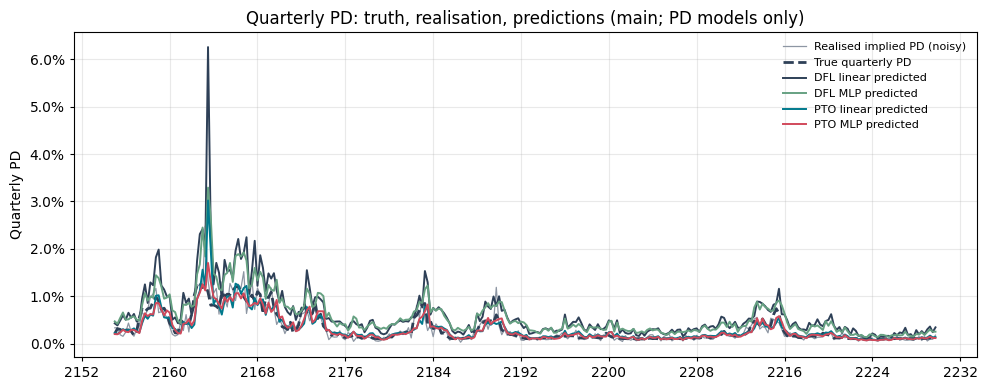

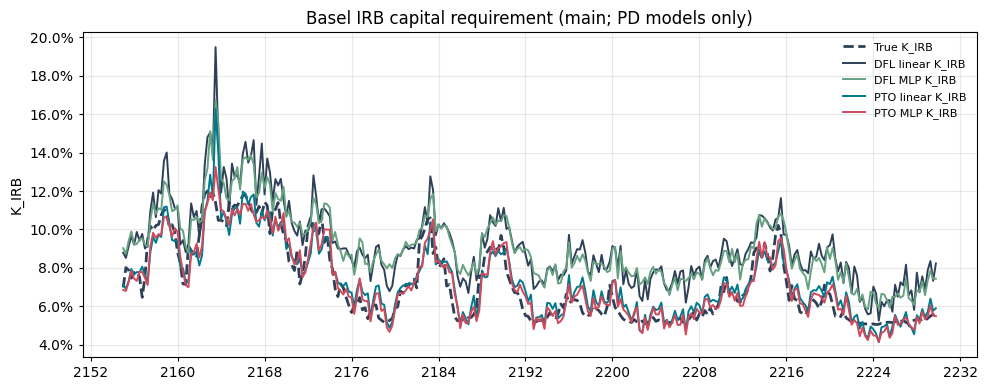

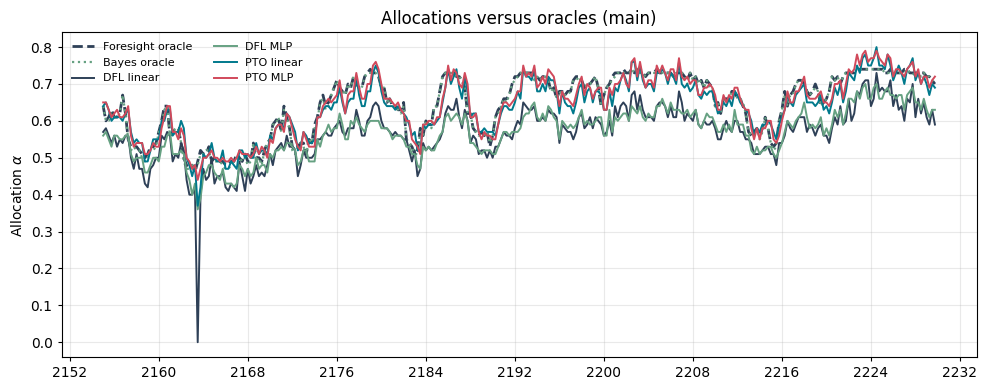

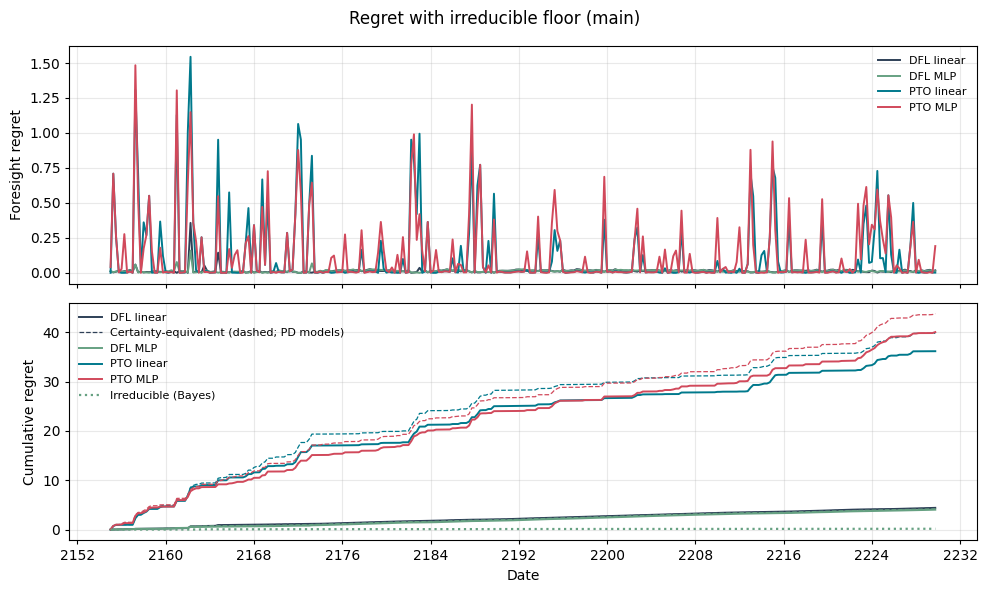

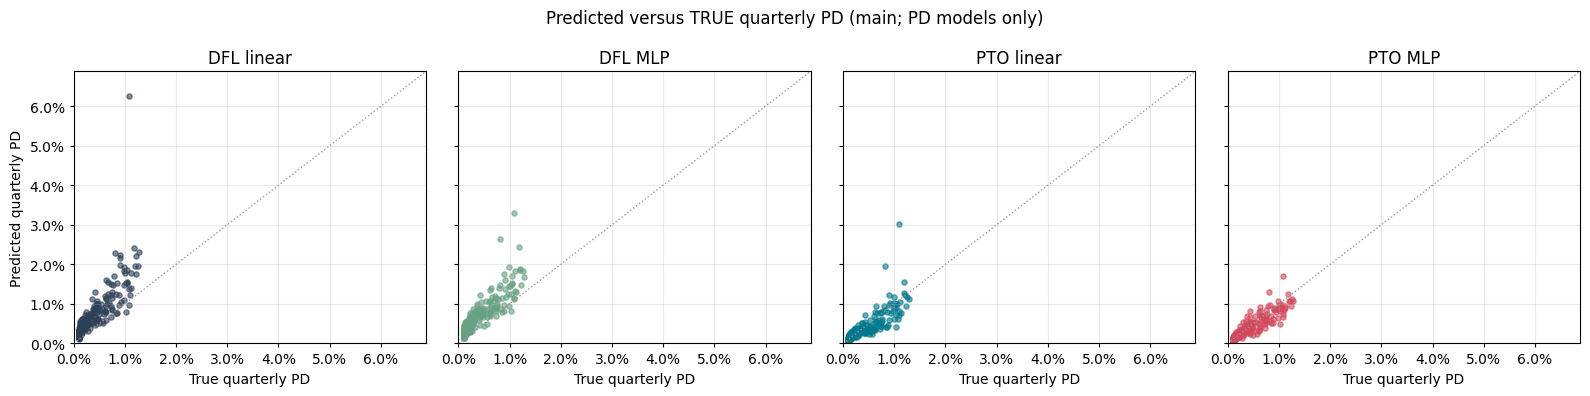

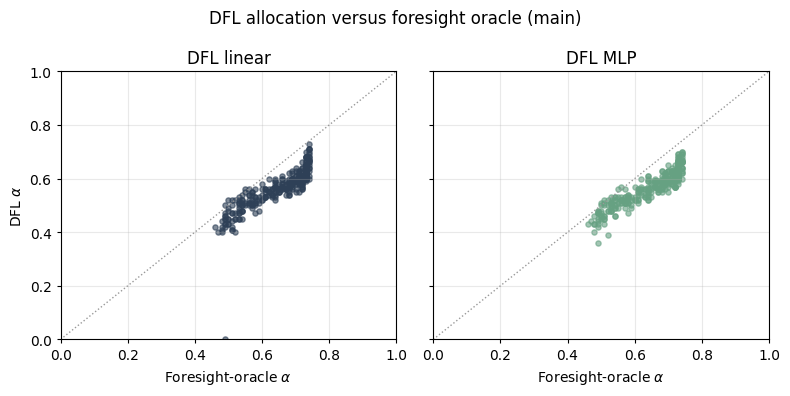

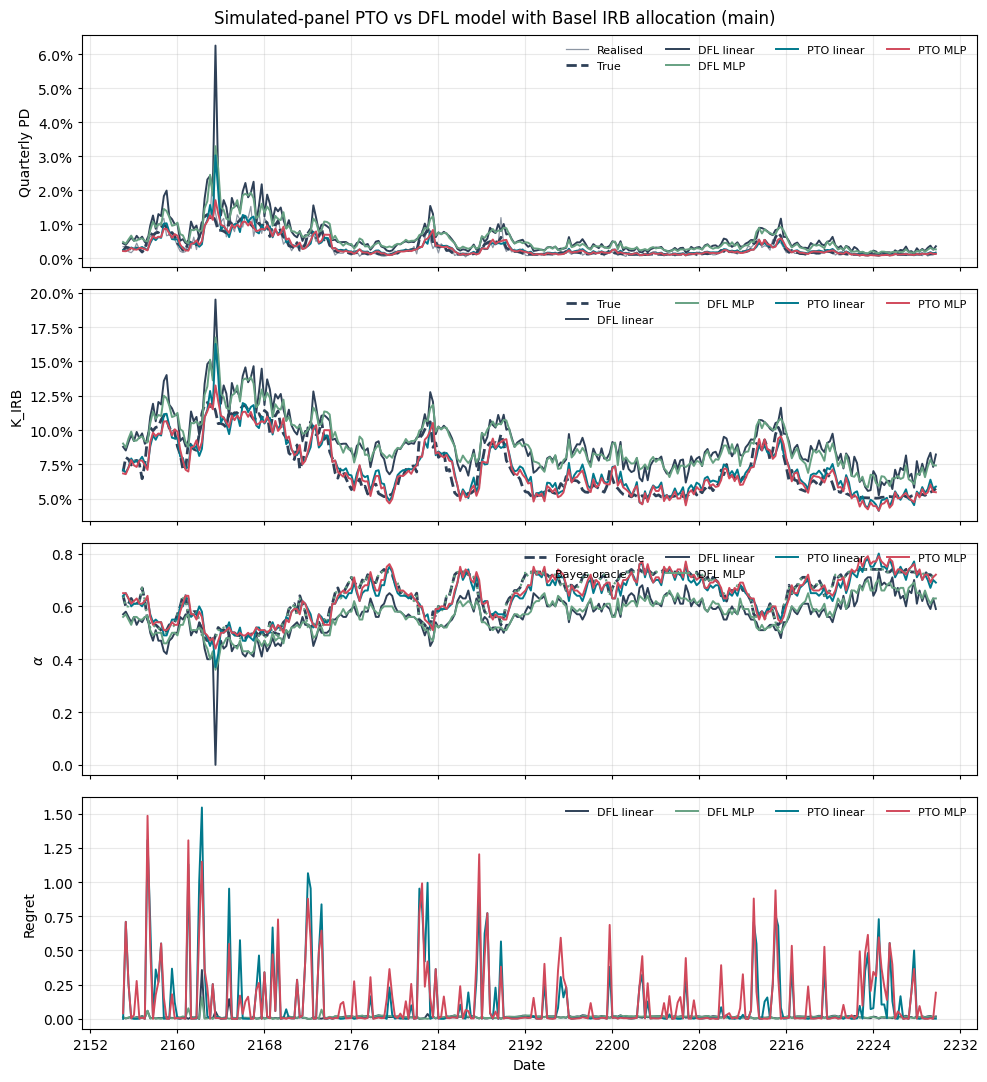

In [28]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
MODEL_COLORS = {"linear": MINOU_COLORS["teal"], "mlp": MINOU_COLORS["coral"], "dfl_linear": MINOU_COLORS["navy"],
                "dfl_mlp": MINOU_COLORS["sage"], "persistence": MINOU_COLORS["grey"], "persistence_ma4": MINOU_COLORS["gold"]}
MODEL_LW = {"linear": 1.4, "mlp": 1.4, "dfl_linear": 1.4, "dfl_mlp": 1.4,
            "persistence": 0.8, "persistence_ma4": 1.2}
MODEL_LABELS = {"linear": "PTO linear", "mlp": "PTO MLP", "dfl_linear": "DFL linear",
                "dfl_mlp": "DFL MLP", "persistence": "Persistence (raw draw)",
                "persistence_ma4": "Persistence (4Q mean)"}
ORACLE_COLOR = MINOU_COLORS["navy"]
BAYES_COLOR = MINOU_COLORS["sage"]
TRUE_COLOR = MINOU_COLORS["navy"]
REALISED_COLOR = MINOU_COLORS["grey"]

# Which models appear in the static figures. Raw persistence is hidden by default (its
# Vasicek noise clouds every panel). PD/K_IRB panels are restricted to PD models; the
# allocation and regret panels include the DFL model. Any subset of MODEL_ORDER works,
# including DFL-only: the PD-based figures are skipped when no PD model is selected.
PLOT_MODELS = ["dfl_linear", "dfl_mlp","linear", "mlp" ] #, "dfl_linear", "dfl_mlp", "persistence_ma4"]
PLOT_MODELS_PD = [m for m in PLOT_MODELS if m in PD_MODELS]
PLOT_MODELS_DFL = [m for m in PLOT_MODELS if m in DFL_MODELS]

def format_date_axis(ax, plot_df):
    years = plot_df["date"].dt.year
    step = max(2, int(np.ceil((years.max() - years.min()) / 10)))
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def _model_lines(ax, plot_df, col_prefix, suffix="", models=None):
    for m in (PLOT_MODELS if models is None else models):
        ax.plot(plot_df["date"], plot_df[f"{col_prefix}_{m}"], color=MODEL_COLORS[m],
                lw=MODEL_LW[m], label=f"{MODEL_LABELS[m]}{suffix}")


def plot_split(res, split_name):
    fig_dir = FIGURES_DIR / split_name
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()

    if PLOT_MODELS_PD:
        # 1. Quarterly PD: truth, noisy realisation, predictions (PD models only)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(plot_df["date"], plot_df["pd_q_realised"], color=REALISED_COLOR, lw=0.9, label="Realised implied PD (noisy)")
        ax.plot(plot_df["date"], plot_df["pd_q_true"], color=TRUE_COLOR, lw=2, ls="--", label="True quarterly PD")
        _model_lines(ax, plot_df, "pd_q_hat", " predicted", models=PLOT_MODELS_PD)
        ax.set_ylabel("Quarterly PD"); ax.set_title(f"Quarterly PD: truth, realisation, predictions ({split_name}; PD models only)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8); plt.tight_layout()
        plt.savefig(fig_dir / "quarterly_pd_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

        # 2. K_IRB: true vs model-implied (PD models only)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(plot_df["date"], plot_df["k_irb_true"], color=TRUE_COLOR, lw=2, ls="--", label="True K_IRB")
        _model_lines(ax, plot_df, "k_irb_hat", " K_IRB", models=PLOT_MODELS_PD)
        ax.set_ylabel("K_IRB"); ax.set_title(f"Basel IRB capital requirement ({split_name}; PD models only)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8); plt.tight_layout()
        plt.savefig(fig_dir / "irb_capital_requirement.png", dpi=200, bbox_inches="tight"); plt.show()
    else:
        print(f"[{split_name}] no PD models in PLOT_MODELS - skipping PD, K_IRB and PD-scatter figures.")

    # 3. Allocations: foresight oracle, Bayes oracle, all selected models
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Foresight oracle")
    ax.plot(plot_df["date"], plot_df["alpha_bayes"], color=BAYES_COLOR, lw=1.6, ls=":", label="Bayes oracle")
    _model_lines(ax, plot_df, "alpha_hat")
    ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title(f"Allocations versus oracles ({split_name})")
    format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8, ncol=2); plt.tight_layout()
    plt.savefig(fig_dir / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

    # 4. Regret and cumulative regret, with the irreducible floor (all selected models)
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ce_labelled = False
    for m in PLOT_MODELS:
        axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        if m in PD_MODELS:
            axes[1].plot(plot_df["date"], plot_df[f"regret_ce_{m}"].cumsum(), color=MODEL_COLORS[m], lw=0.9, ls="--",
                         label="Certainty-equivalent (dashed; PD models)" if not ce_labelled else "_nolegend_")
            ce_labelled = True
    axes[1].plot(plot_df["date"], plot_df["regret_irreducible"].cumsum(), color=BAYES_COLOR, lw=1.6, ls=":",
                 label="Irreducible (Bayes)")
    axes[0].set_ylabel("Foresight regret"); axes[0].legend(frameon=False, fontsize=8)
    axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False, fontsize=8)
    for ax in axes:
        format_date_axis(ax, plot_df)
    fig.suptitle(f"Regret with irreducible floor ({split_name})"); plt.tight_layout()
    plt.savefig(fig_dir / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

    # 5. Predicted vs TRUE PD scatter (PD models only - skipped when none selected)
    if PLOT_MODELS_PD:
        fig, axes = plt.subplots(1, len(PLOT_MODELS_PD), figsize=(4 * len(PLOT_MODELS_PD), 4), sharex=True, sharey=True)
        lims = [0.0, max(plot_df["pd_q_true"].max(), *(plot_df[f"pd_q_hat_{m}"].max() for m in PLOT_MODELS_PD)) * 1.1]
        for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS_PD):
            ax.scatter(plot_df["pd_q_true"], plot_df[f"pd_q_hat_{m}"], s=14, color=MODEL_COLORS[m], alpha=0.6)
            ax.plot(lims, lims, color="#999999", lw=1, ls=":")
            ax.set_xlim(lims); ax.set_ylim(lims)
            ax.set_title(MODEL_LABELS[m]); ax.set_xlabel("True quarterly PD")
            ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
            ax.grid(True, alpha=0.28)
        np.atleast_1d(axes)[0].set_ylabel("Predicted quarterly PD")
        fig.suptitle(f"Predicted versus TRUE quarterly PD ({split_name}; PD models only)")
        plt.tight_layout(); plt.savefig(fig_dir / "pred_vs_true_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

    # 6. DFL alpha vs oracle alpha scatter (skipped when no DFL model selected)
    if PLOT_MODELS_DFL:
        fig, axes = plt.subplots(1, len(PLOT_MODELS_DFL), figsize=(4 * len(PLOT_MODELS_DFL), 4), sharex=True, sharey=True)
        for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS_DFL):
            ax.scatter(plot_df["alpha_oracle"], plot_df[f"alpha_hat_{m}"], s=14, color=MODEL_COLORS[m], alpha=0.6)
            ax.plot([0, 1], [0, 1], color="#999999", lw=1, ls=":")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.set_title(MODEL_LABELS[m]); ax.set_xlabel(r"Foresight-oracle $\alpha$")
            ax.grid(True, alpha=0.28)
        np.atleast_1d(axes)[0].set_ylabel(r"DFL $\alpha$")
        fig.suptitle(f"DFL allocation versus foresight oracle ({split_name})")
        plt.tight_layout(); plt.savefig(fig_dir / "dfl_alpha_vs_oracle_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

    # 7. Compact 4-panel thesis figure (PD rows show PD models only; empty when none selected)
    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    axes[0].plot(plot_df["date"], plot_df["pd_q_realised"], color=REALISED_COLOR, lw=0.9, label="Realised")
    axes[0].plot(plot_df["date"], plot_df["pd_q_true"], color=TRUE_COLOR, lw=2, ls="--", label="True")
    _model_lines(axes[0], plot_df, "pd_q_hat", models=PLOT_MODELS_PD)
    axes[0].set_ylabel("Quarterly PD"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].plot(plot_df["date"], plot_df["k_irb_true"], color=TRUE_COLOR, lw=2, ls="--", label="True")
    _model_lines(axes[1], plot_df, "k_irb_hat", models=PLOT_MODELS_PD)
    axes[1].set_ylabel("K_IRB"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[2].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Foresight oracle")
    axes[2].plot(plot_df["date"], plot_df["alpha_bayes"], color=BAYES_COLOR, lw=1.6, ls=":", label="Bayes oracle")
    _model_lines(axes[2], plot_df, "alpha_hat")
    axes[2].set_ylabel(r"$\alpha$")
    for m in PLOT_MODELS:
        axes[3].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[3].set_ylabel("Regret"); axes[3].set_xlabel("Date")
    for ax in axes:
        format_date_axis(ax, plot_df); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=4)
    fig.suptitle(f"Simulated-panel PTO vs DFL model with Basel IRB allocation ({split_name})", fontsize=12)
    plt.tight_layout(); plt.savefig(fig_dir / "dfl_sim_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()


for split_name, res in results_by_split.items():
    plot_split(res, split_name)



## Learning curves

Averaged across refits within each split; the MLP curve is the first ensemble seed only.
Averaged across refits within each split (MLP/DFL curves use the first ensemble
seed only). Early-stopped refits are padded by carrying the last value forward so the
per-epoch mean keeps constant composition. PD models: val RMSE in sim sits at the Vasicek
noise floor (~0.011), so judge convergence on the NLL panel. The DFL model gets its own
panel: validation REGRET, its early-stopping criterion.


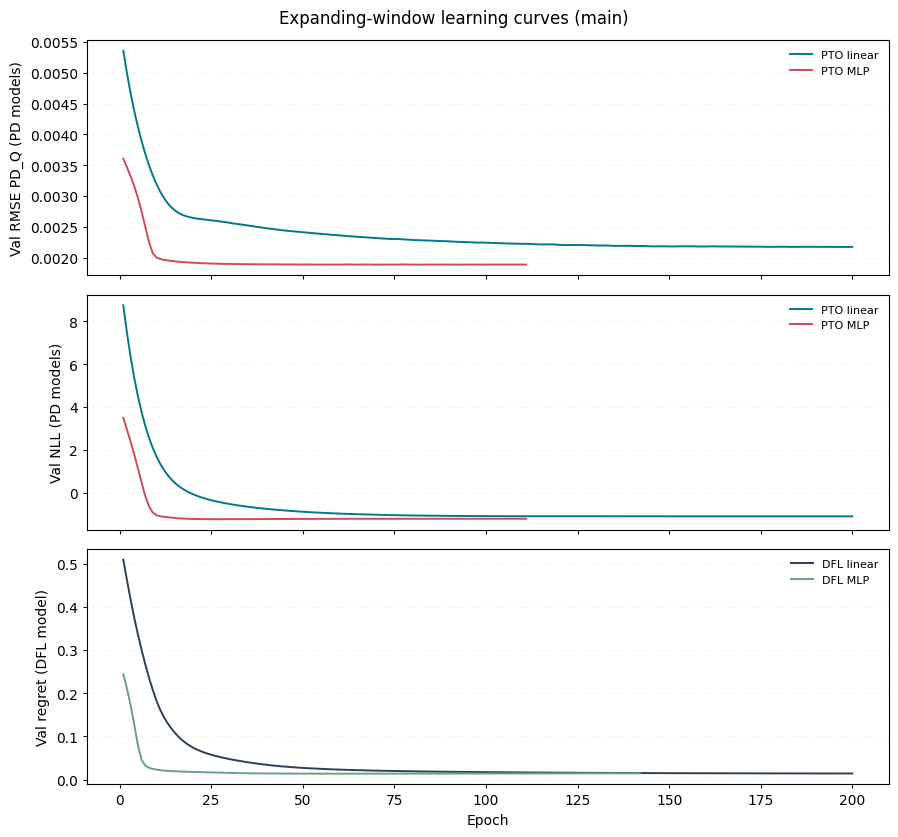

In [29]:
if not training_history.empty:
    for split_name, split_hist in training_history.groupby("split"):
        # Pad each refit's history to the model's max epoch (last value carried forward)
        # so the per-epoch mean has constant composition despite early stopping.
        padded = []
        for model_name, mg in split_hist.groupby("model"):
            max_epoch = int(mg["epoch"].max())
            for _, g in mg.groupby("test_date"):
                gg = (g.sort_values("epoch").set_index("epoch")[["val_rmse_pd_q", "val_loss"]]
                       .reindex(range(1, max_epoch + 1)).ffill().reset_index())
                gg["model"] = model_name
                padded.append(gg)
        mean_history = (pd.concat(padded, ignore_index=True)
                        .groupby(["model", "epoch"], as_index=False)
                        .agg(mean_val_rmse_pd_q=("val_rmse_pd_q", "mean"), mean_val_loss=("val_loss", "mean")))

        fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True)
        for model_name, group in mean_history.groupby("model"):
            group = group.sort_values("epoch"); color = MODEL_COLORS.get(model_name, "grey")
            label = MODEL_LABELS.get(model_name, model_name.upper())
            if model_name in DFL_MODELS:
                axes[2].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
            elif model_name in ("linear", "mlp"):
                axes[0].plot(group["epoch"], group["mean_val_rmse_pd_q"], color=color, lw=1.4, label=label)
                axes[1].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
        axes[0].set_ylabel("Val RMSE PD_Q (PD models)")
        loss_space = "NLL" if LOSS == "nll_vasicek" else f"MSE ({TARGET_TRANSFORM} space)"
        axes[1].set_ylabel(f"Val {loss_space} (PD models)")
        axes[2].set_ylabel("Val regret (DFL model)"); axes[2].set_xlabel("Epoch")
        for ax in axes:
            ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle(f"Expanding-window learning curves ({split_name})"); plt.tight_layout()
        fig_dir = FIGURES_DIR / split_name
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()


In [30]:
BB_RESULTS_PREFIX = "blackbox_sim"
## Cross-notebook comparison vs the black box (shared test dates)

# The black-box notebook saves per-date predictions to RESULTS_DIR; if present, compare
# DFL vs black-box regret with the same DM machinery on the shared dates. Run the
# black-box notebook first (or skip - this cell is a no-op if the CSV is absent).
for split_name in EVAL_SPLITS:
    bb_csv = ROOT / "models" / "notebooks" / "results" / "simulation" / "blackbox" / f"{BB_RESULTS_PREFIX}_predictions_{split_name}.csv"
    if not bb_csv.exists():
        print(f"[{split_name}] {bb_csv.name} not found - run the black-box notebook for this comparison.")
        continue
    bb = pd.read_csv(bb_csv, parse_dates=["date"])
    ours = results_by_split[split_name][["date", "regret_dfl_linear", "regret_dfl_mlp"]]
    merged = ours.merge(bb[["date", "regret_blackbox_linear", "regret_blackbox_mlp"]], on="date", how="inner")
    print(f"=== {split_name}: DFL vs black box on {len(merged)} shared dates ===")
    rows = []
    for a, b in [("regret_dfl_linear", "regret_blackbox_linear"), ("regret_dfl_mlp", "regret_blackbox_mlp")]:
        stat, p = dm_test(merged[a].to_numpy(), merged[b].to_numpy())
        rows.append({"pair": f"{a.replace('regret_', '')} vs {b.replace('regret_', '')}",
                     "mean_regret_dfl": float(merged[a].mean()), "mean_regret_bb": float(merged[b].mean()),
                     "dm_regret": stat, "p_regret": p})
    display(pd.DataFrame(rows).set_index("pair"))

=== main: DFL vs black box on 300 shared dates ===


,mean_regret_dfl,mean_regret_bb,dm_regret,p_regret
pair,,,,
dfl_linear vs blackbox_linear,0.014710,0.016133,-0.912183,0.362407
dfl_mlp vs blackbox_mlp,0.013457,0.014720,-1.368000,0.172339
